In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

L = 32 #number of lattice points in each dimension
size = L #total number of lattice points
J = 1.0  #Coupling Coefficient
N = 250 #number of monte-carlo steps for data collection
Neq = 250 #number of MCS for equilibration
Nt = 200 #number of temperatures sampled
Temps = np.logspace(-2,1.5,Nt)

#Data Collection
M_t = np.zeros(N) #magnetization
E_t = np.zeros(N) #energy per spin/lattice point
E2_t = np.zeros(N) #energy^2 per spin/lattice point
s_T = []
M_T = np.zeros(Nt)
E_T = np.zeros(Nt)
Cv_T = np.zeros(Nt)

#Iterate over Temps
Tcounter = 0
for T in Temps:
    #Begin in Random Initial State
    state = np.random.choice([-1,1],L)
    state_i = state.copy()
    #Begin Iteration of MCS (monte-carlo steps)
    for n_out in range(N+Neq):
        if n_out >= Neq:
            #compute and store magnetization
            M_t[n_out-Neq] = np.sum(state)/size
            #compute and store energy per spin
            E_t[n_out-Neq] = -J*np.sum(state*np.roll(state,1))/size
            #compute and store E^2 per spin
            E2_t[n_out-Neq] = E_t[n_out-Neq]**2
        #For each MCS, attempt flipping one spin for every lattice point
        randx = np.random.randint(0,L,size)
        for n_in in range(size):
            #choose a random lattice point
            xpos = randx[n_in]
            xp = xpos+1
            if xp == L:
                xp = 0
            xm = xpos-1
            #calculate change in energy of prospective flip
            dU = 2*J*state[xpos]*(state[xm] + state[xp])
            #decide whether to flip
            if dU <= 0:
                state[xpos] *= -1
            elif np.random.rand() < np.exp(-dU/T):
                state[xpos] *= -1
    M_T[Tcounter] = stats.mode(np.abs(M_t),axis=None)[0]
    E_T[Tcounter] = np.sum(E_t)/(N)
    Cv_T[Tcounter] = ((np.sum(E2_t)/N)-(E_T[Tcounter]**2))/(T**2)
    state_f = state.copy()
    s_T.append((state_i,state_f))
    Tcounter += 1


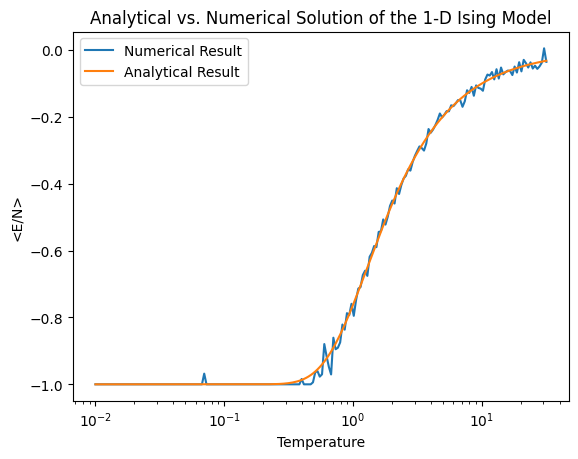

In [126]:
#Analytical Solution:
exactE_T = np.array([-J*np.tanh(J/T) for T in Temps])
#Plot <E/N>(T)
plt.plot(Temps,E_T, label='Numerical Result')
plt.plot(Temps, exactE_T, label='Analytical Result')
plt.title("Analytical vs. Numerical Solution of the 1-D Ising Model")
plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("<E/N>")
plt.legend()
#plt.savefig(f'Figures/1D/1D-EnergyComparison.jpg')
plt.show()

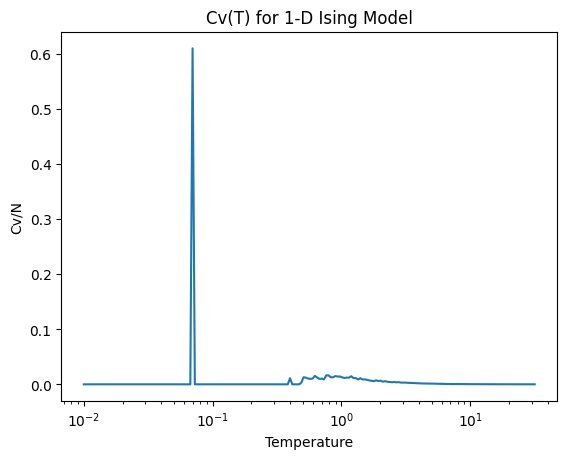

In [127]:
#Plot Cv(T)/N
plt.plot(Temps,Cv_T, label='Numerical Result')
#plt.plot(Temps, exactCv_T, label='Analytical Result')
plt.title("Cv(T) for 1-D Ising Model")
plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("Cv/N")
#plt.legend()
#plt.savefig(f'Figures/1D/1D-EnergyComparison.jpg')
plt.show()

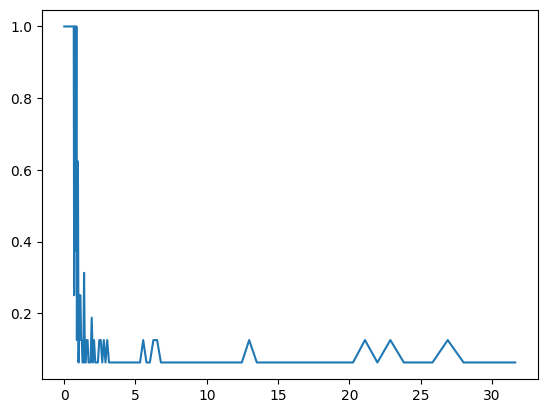

In [128]:
#Plot <M>(T)
plt.plot(Temps,M_T)
#plt.xscale('log')
plt.show()

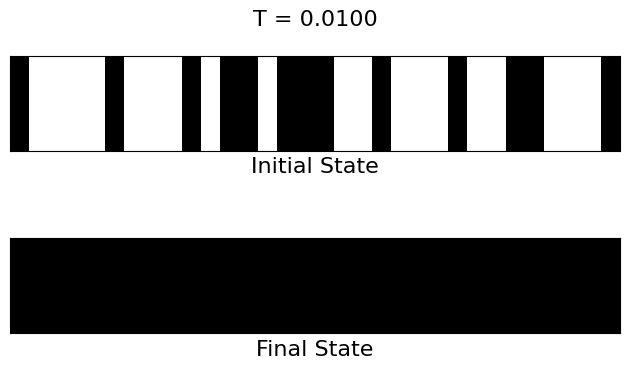

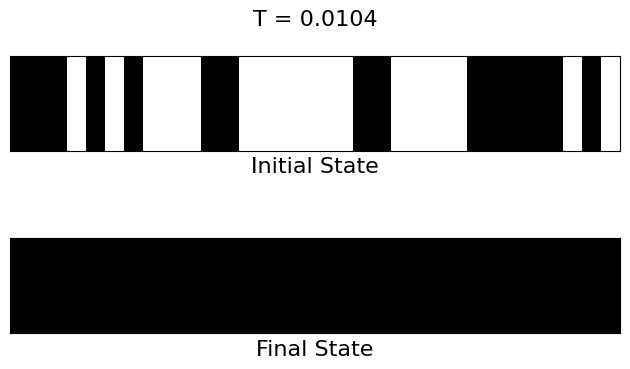

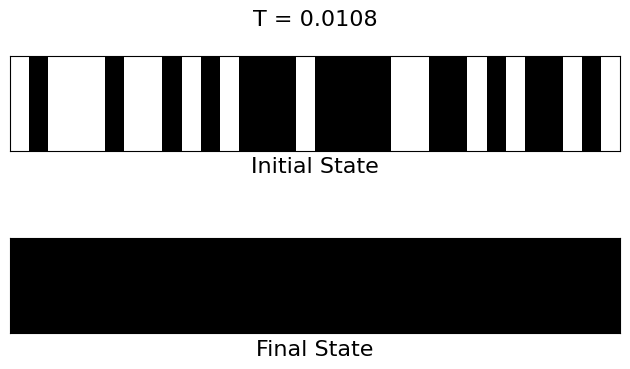

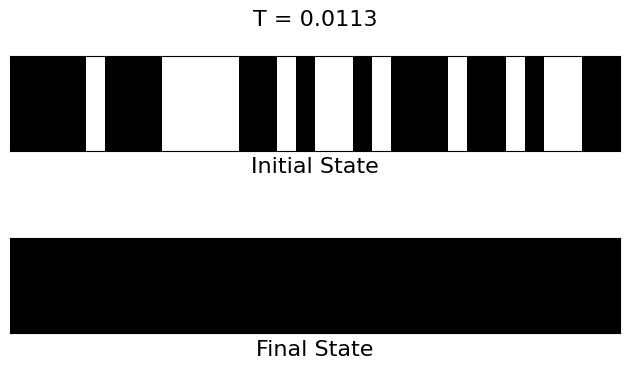

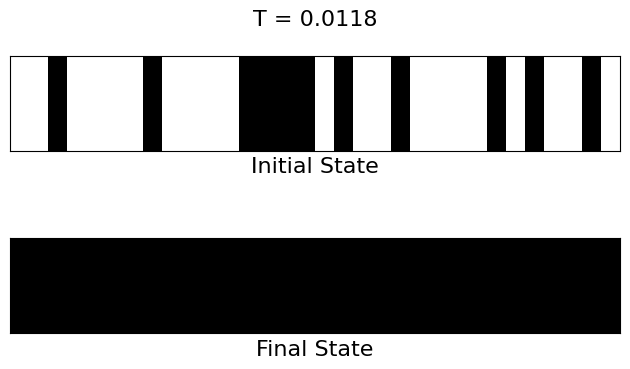

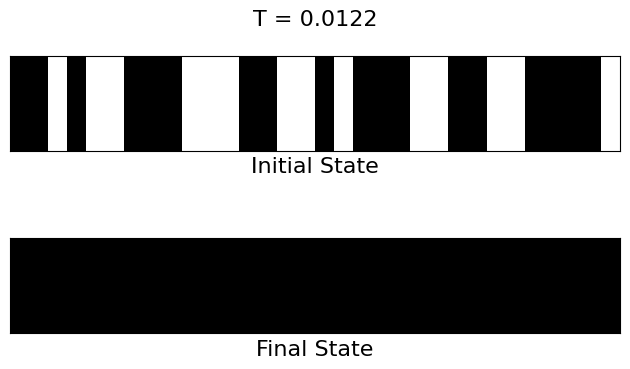

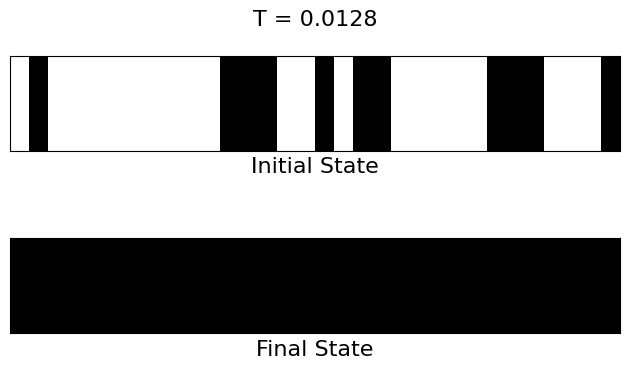

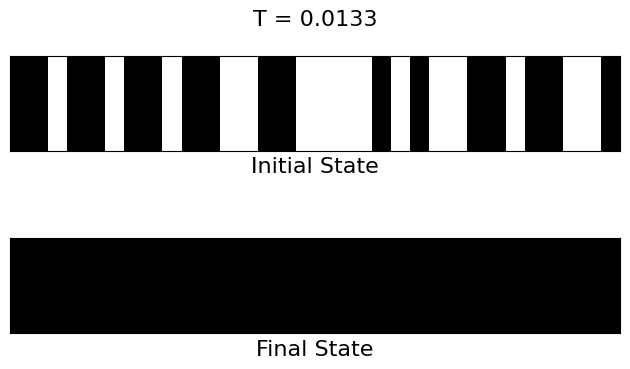

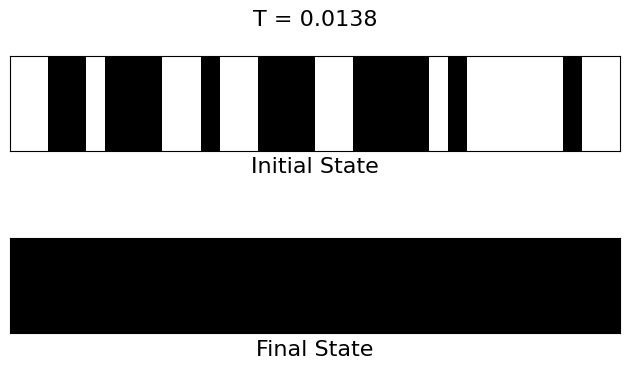

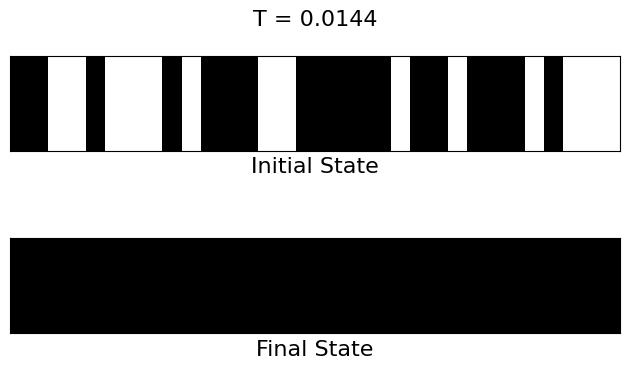

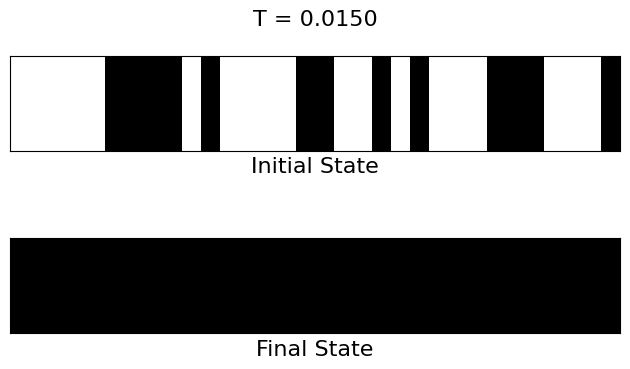

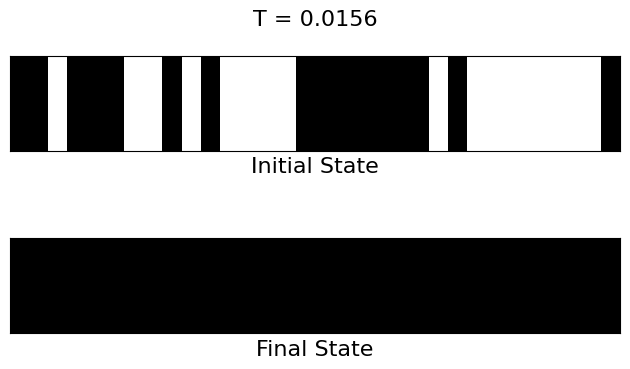

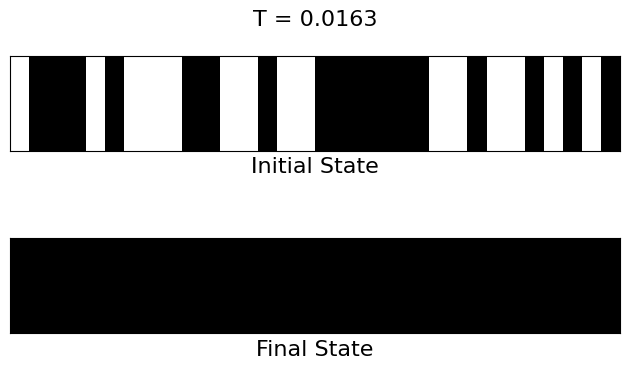

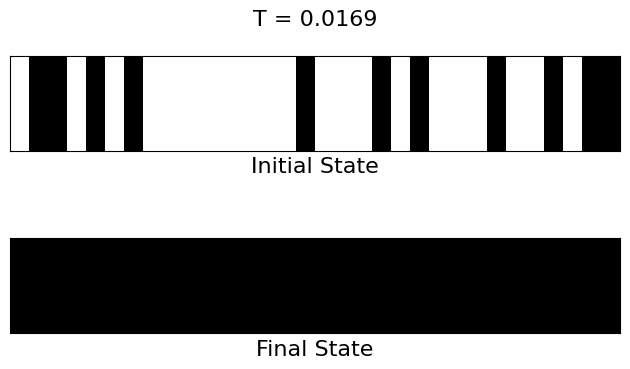

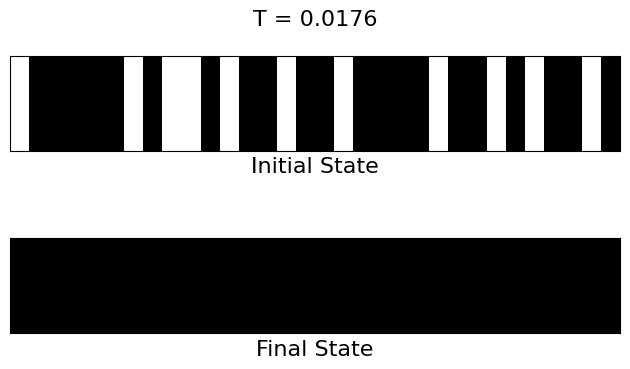

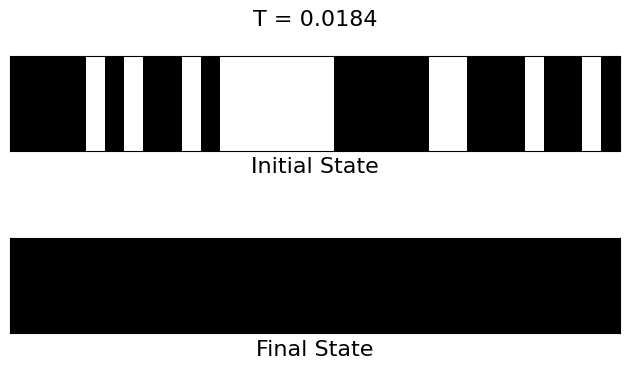

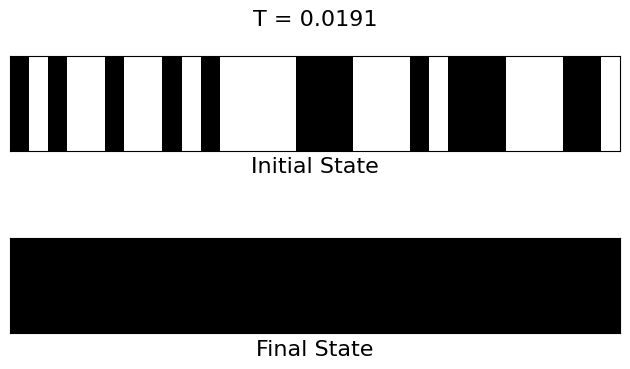

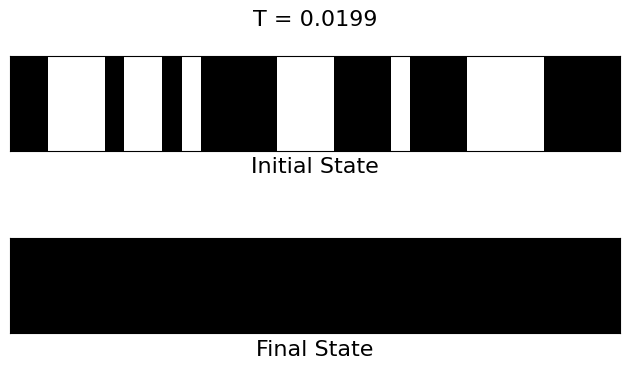

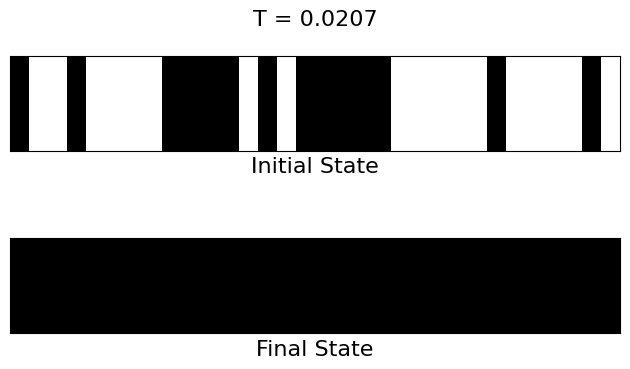

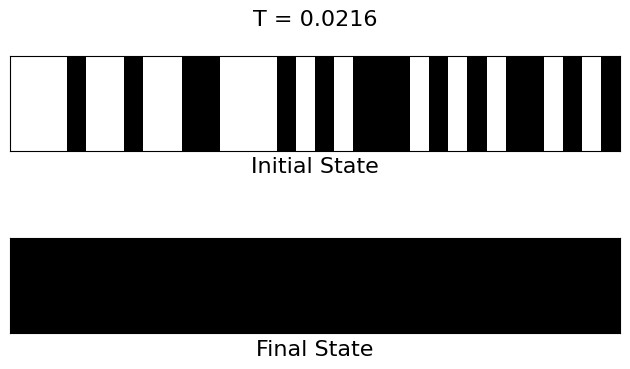

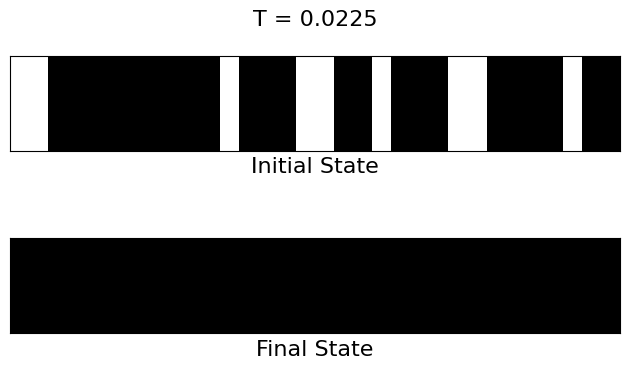

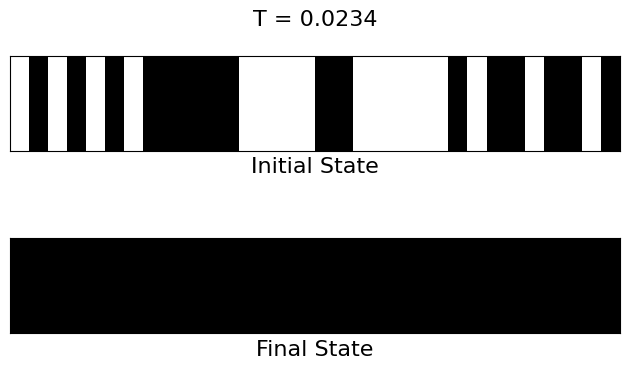

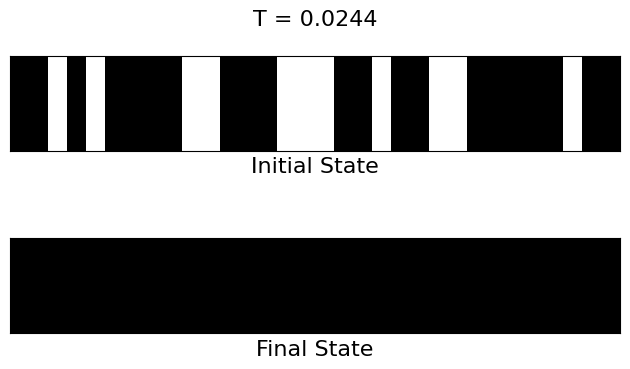

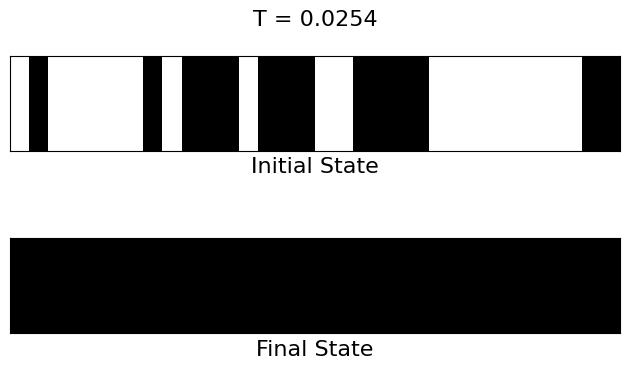

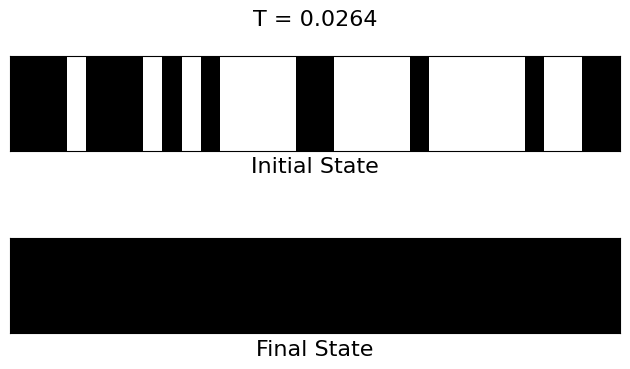

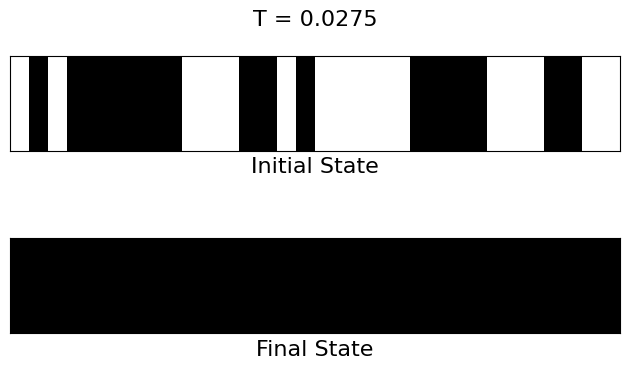

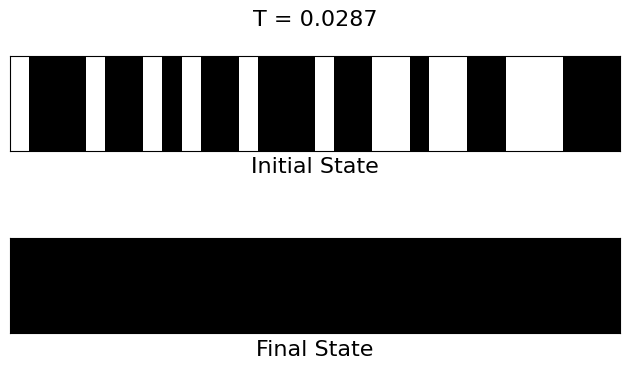

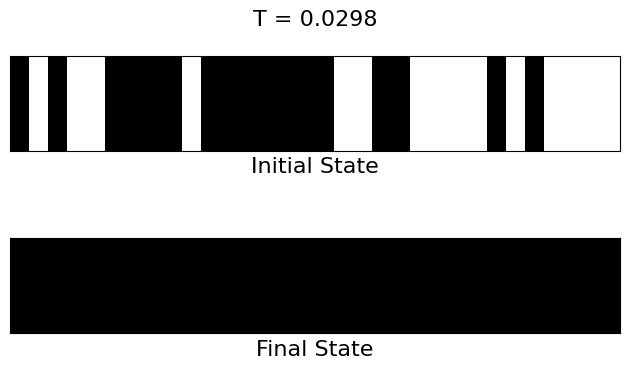

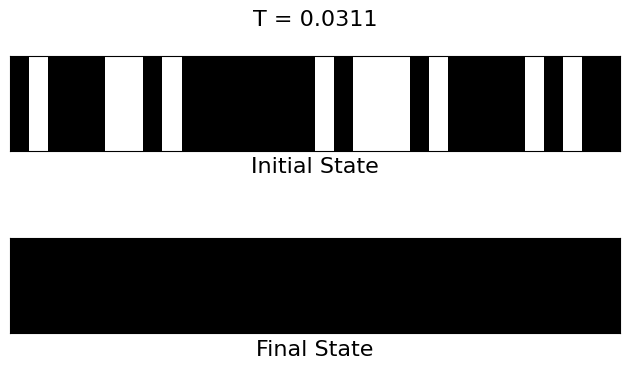

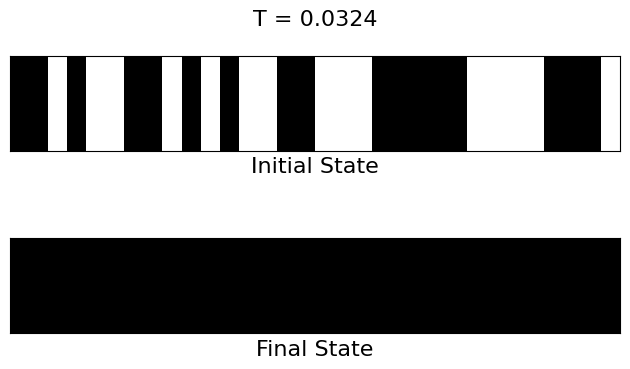

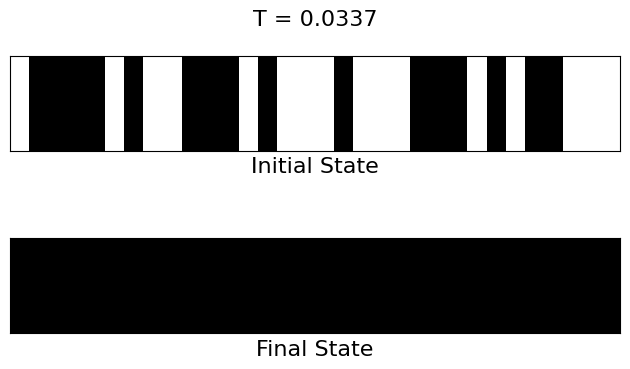

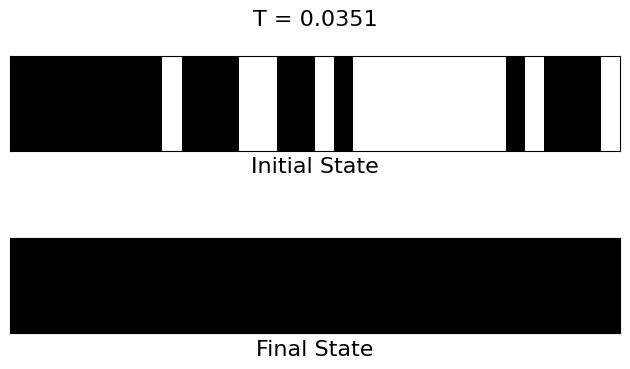

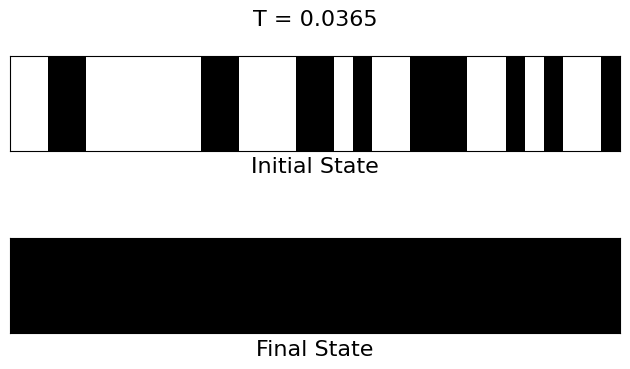

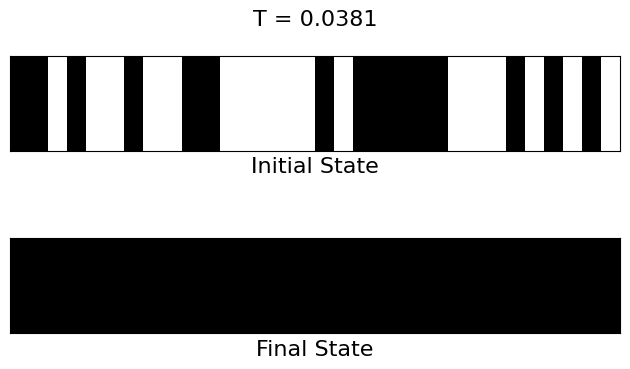

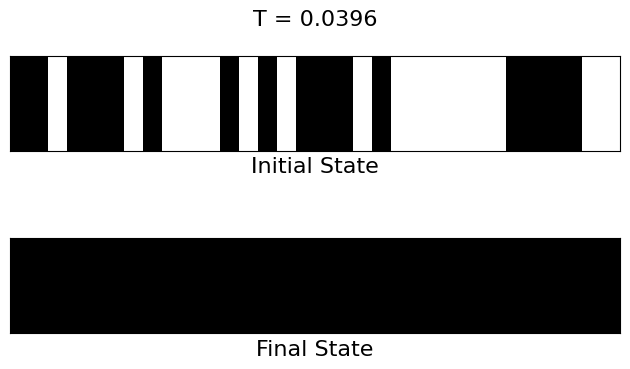

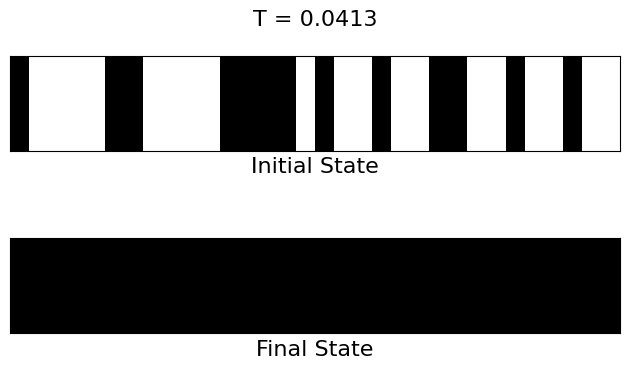

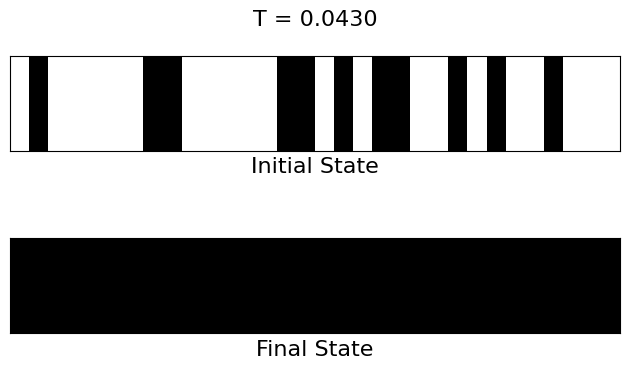

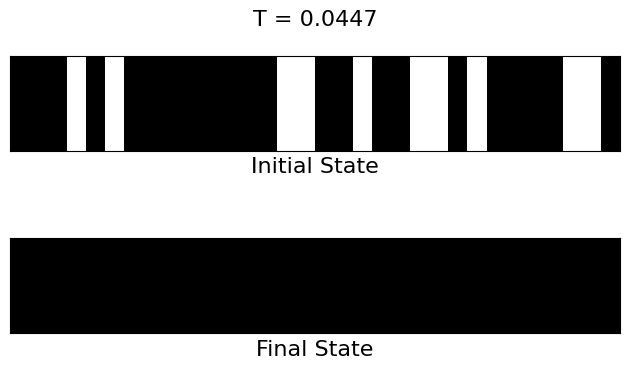

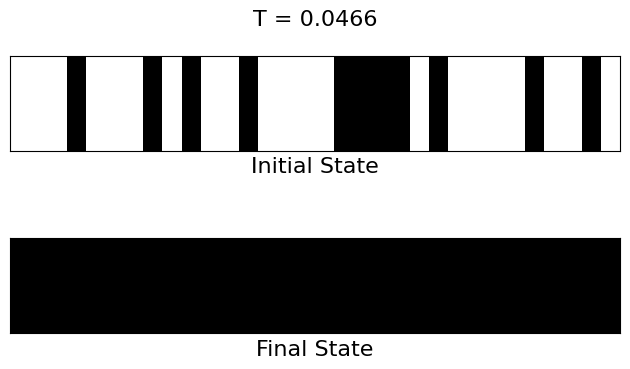

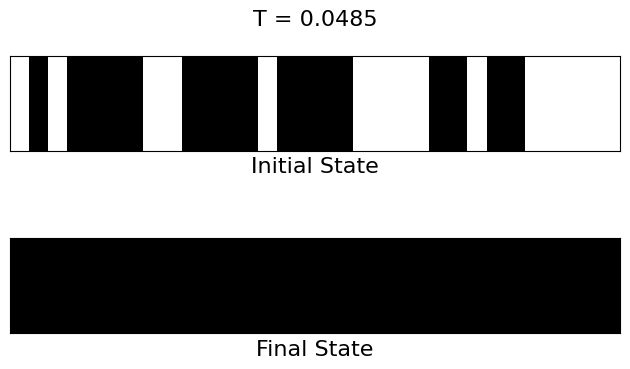

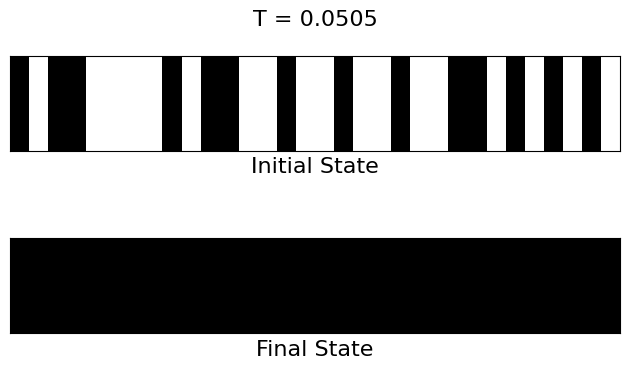

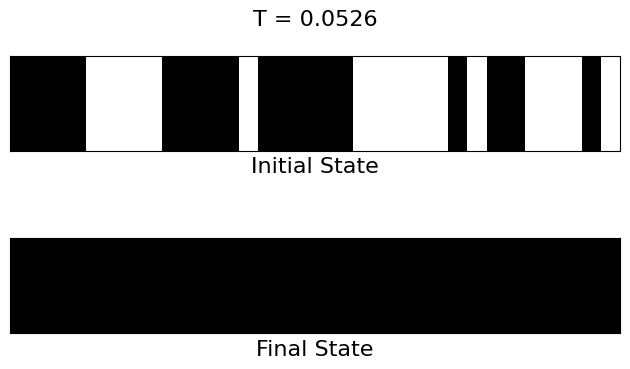

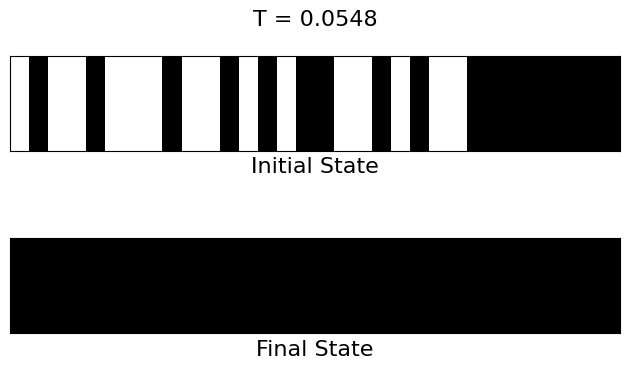

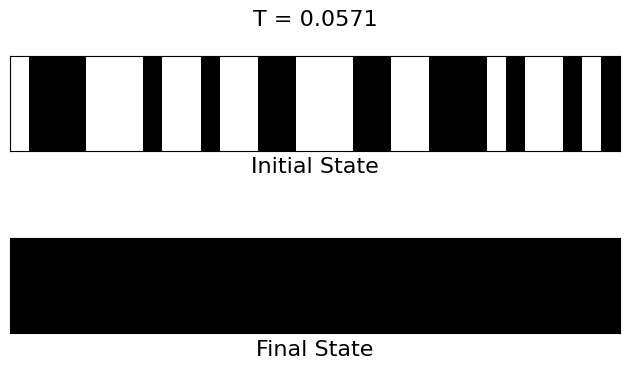

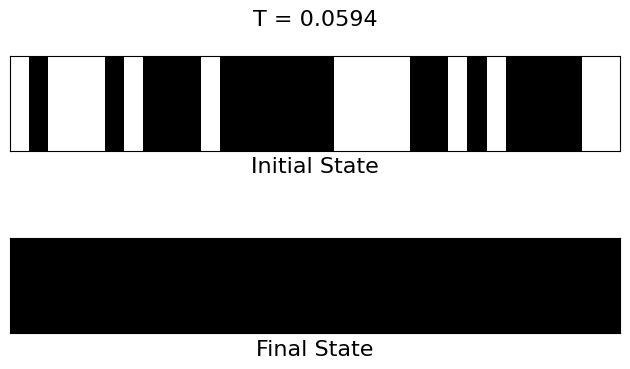

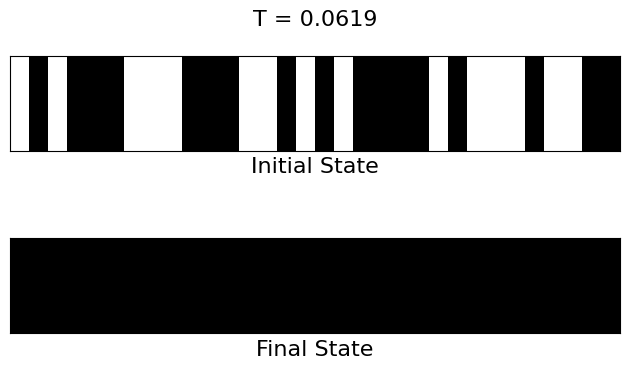

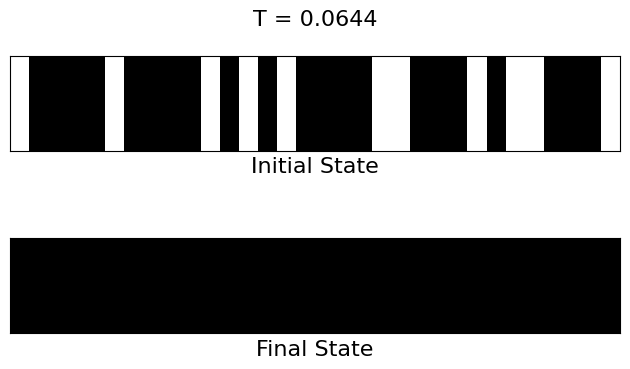

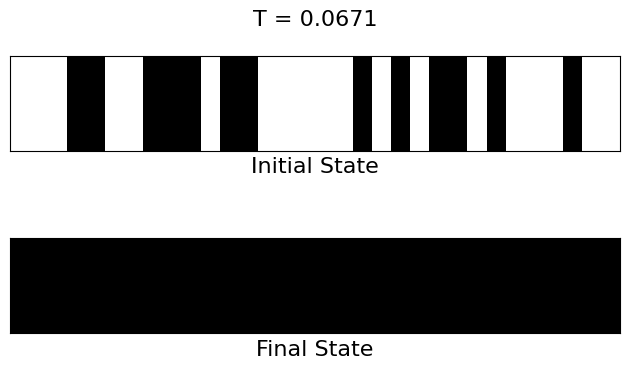

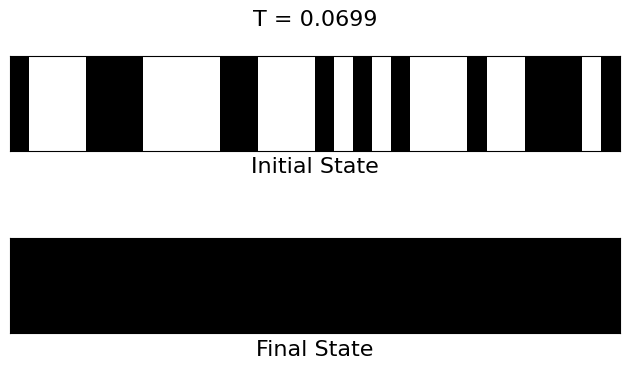

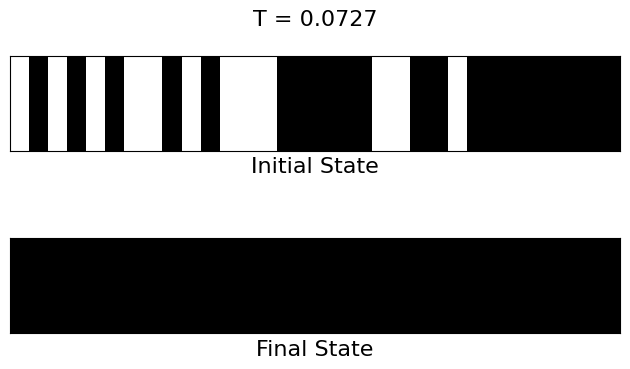

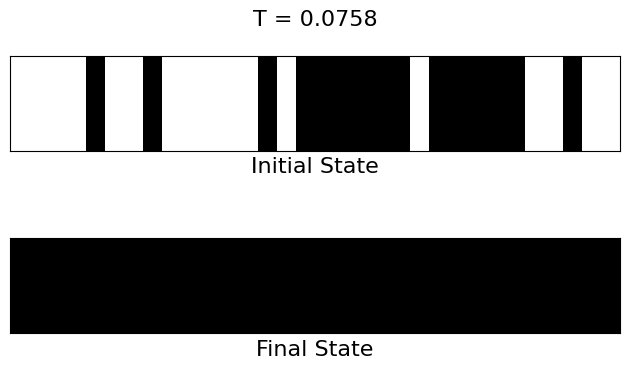

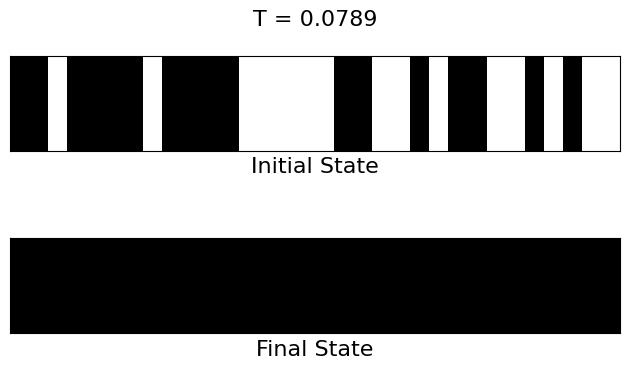

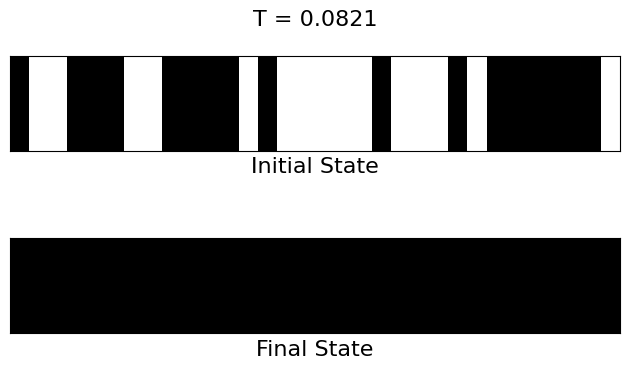

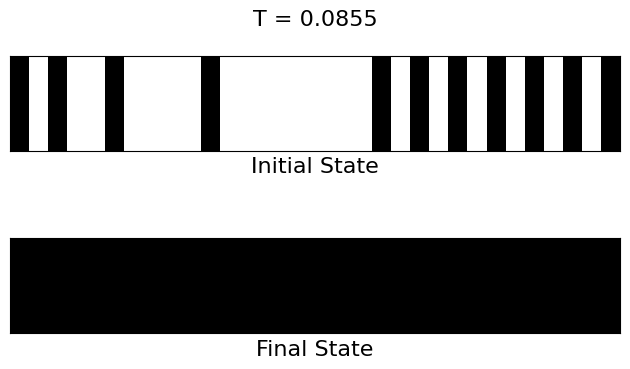

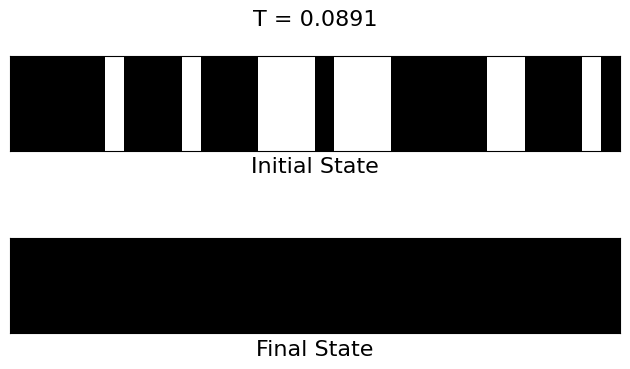

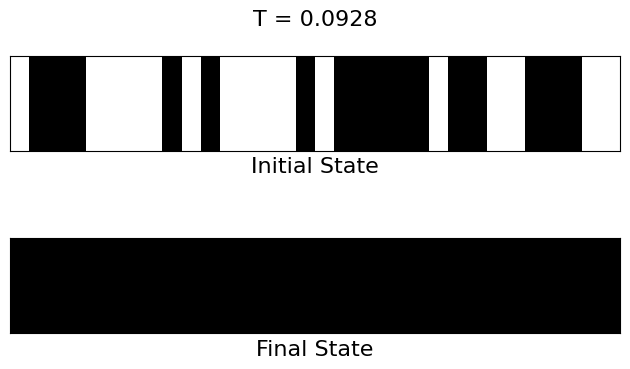

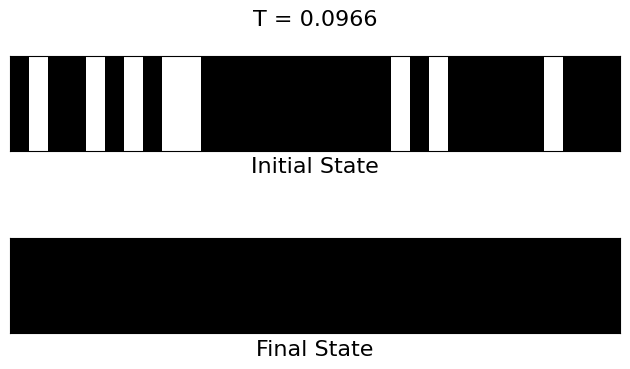

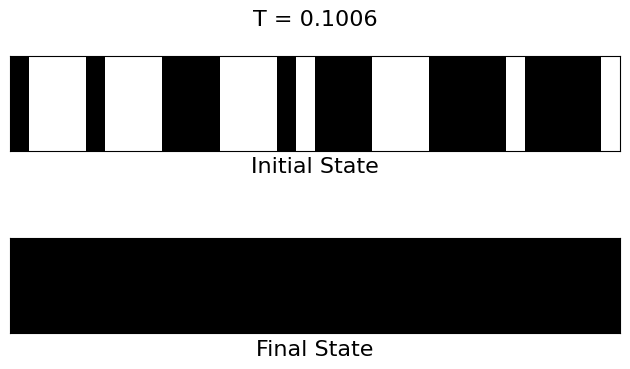

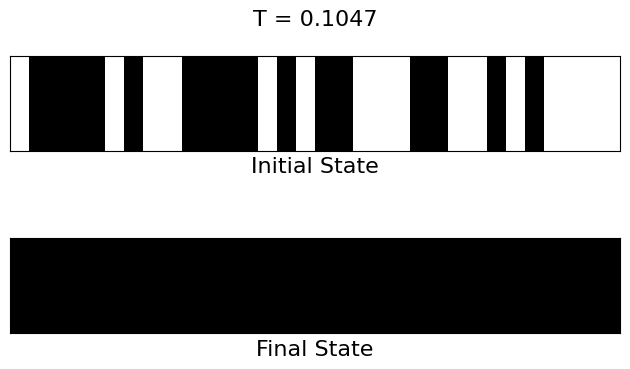

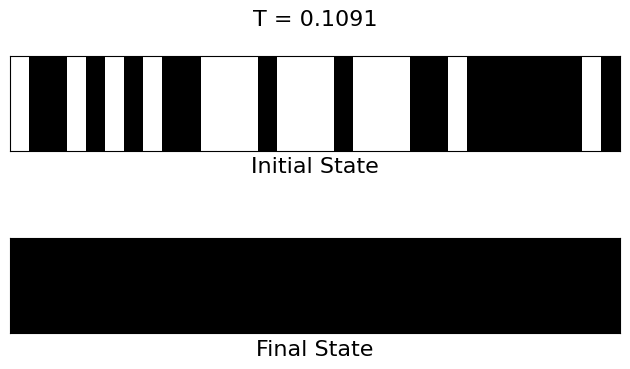

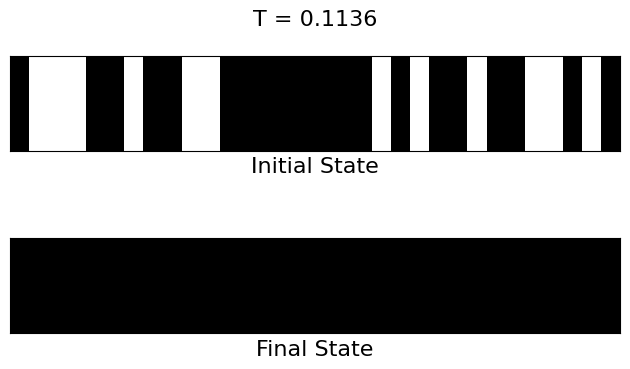

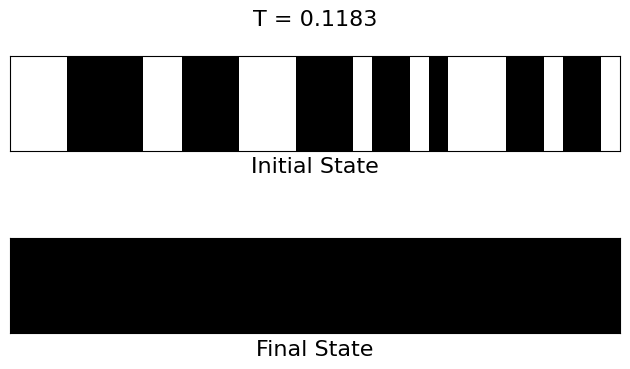

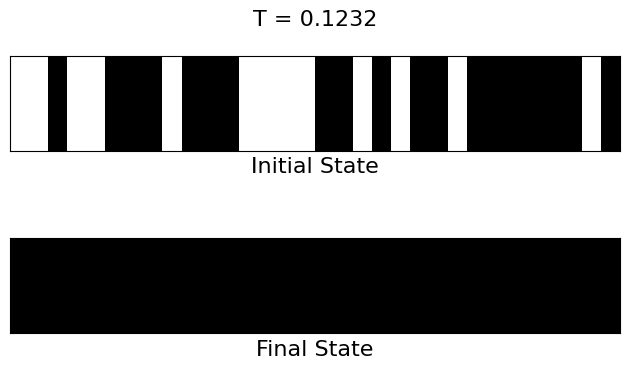

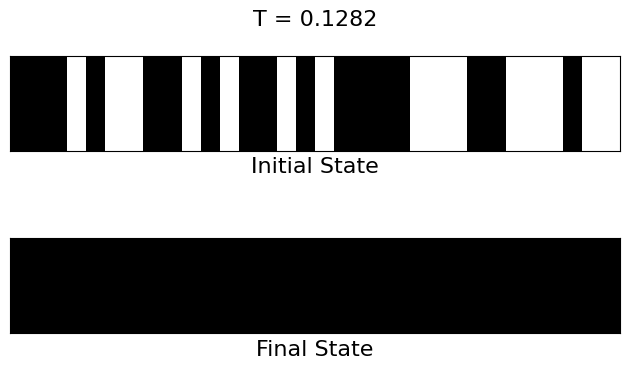

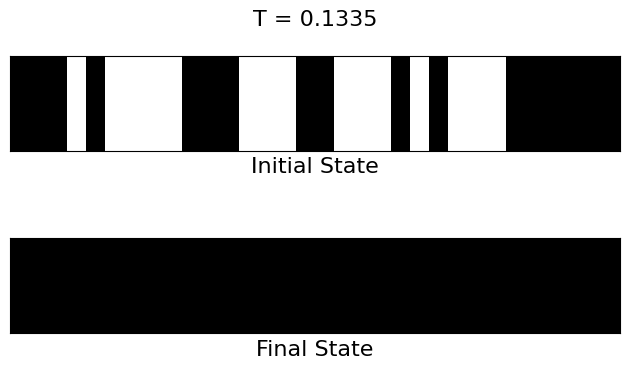

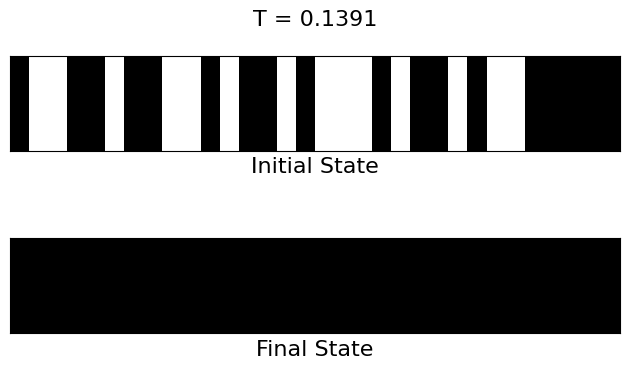

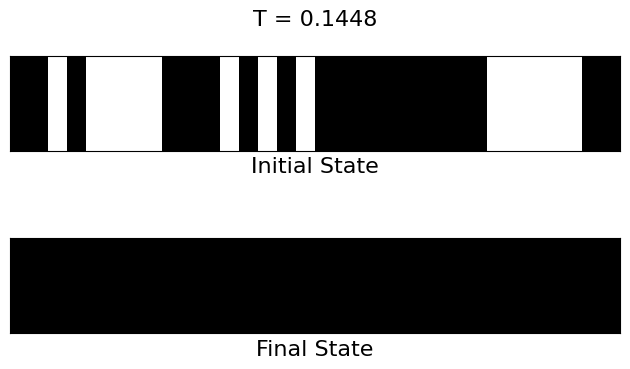

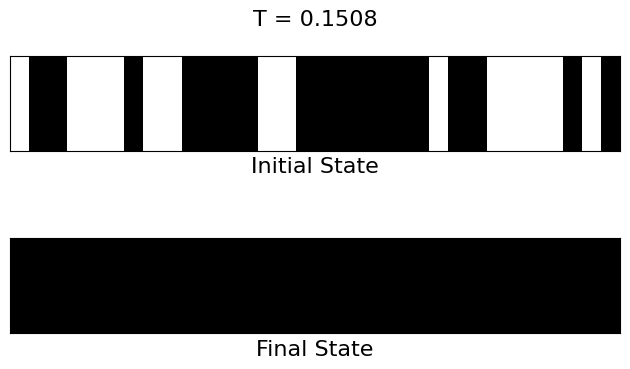

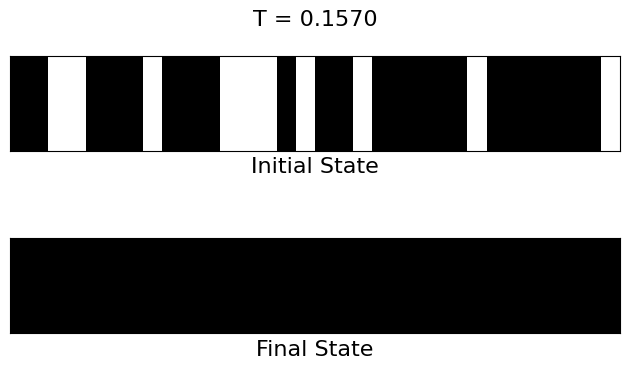

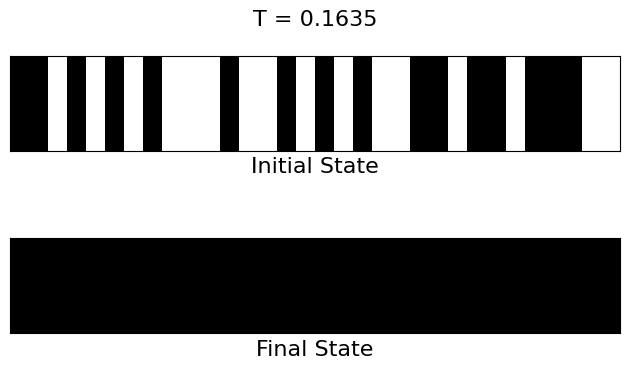

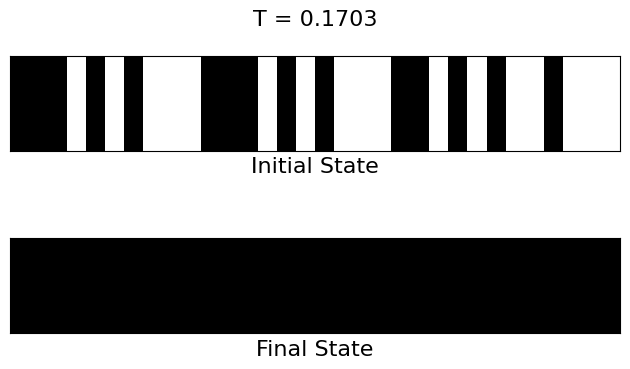

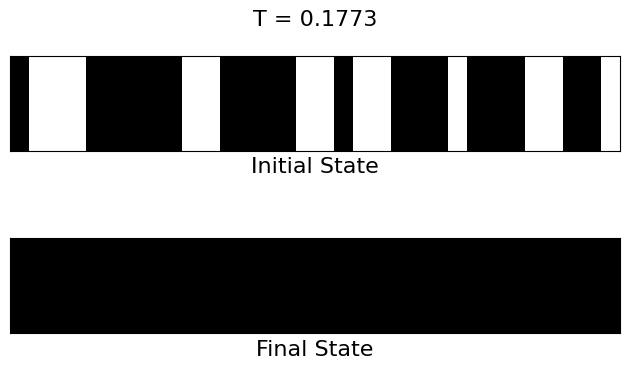

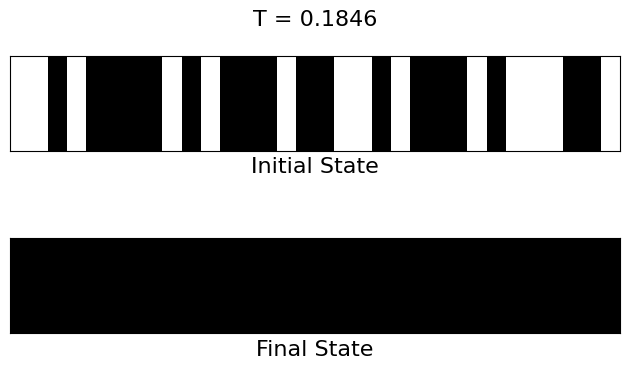

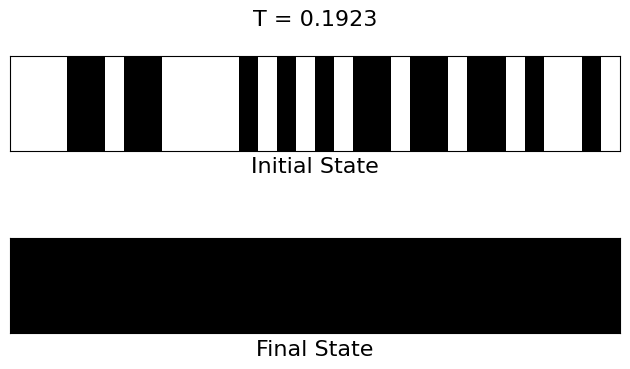

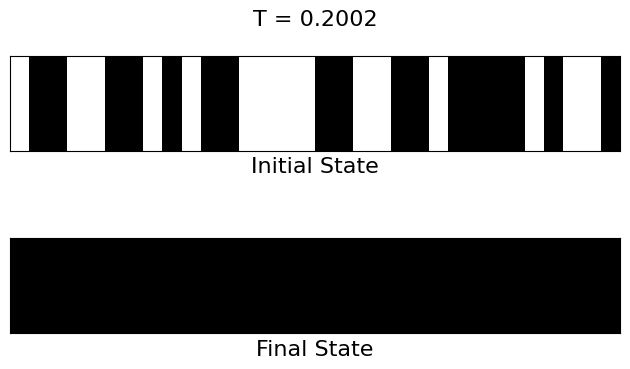

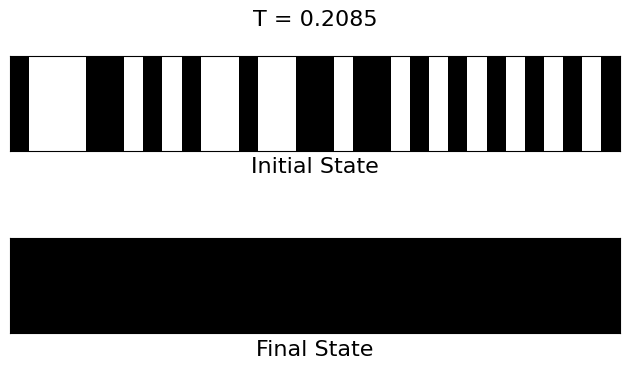

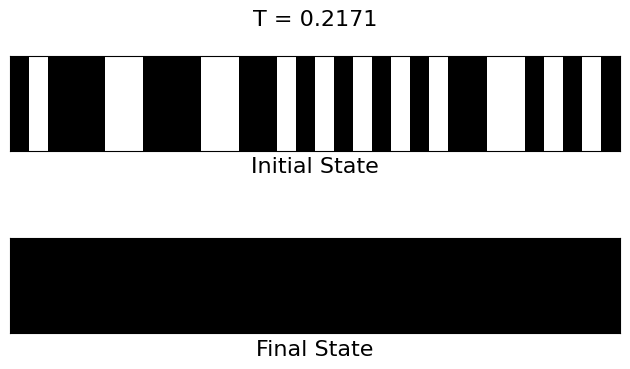

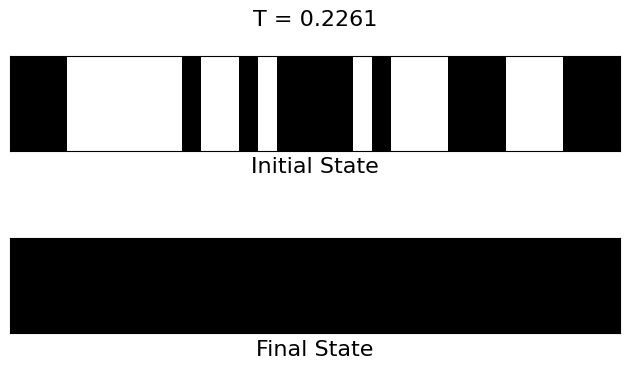

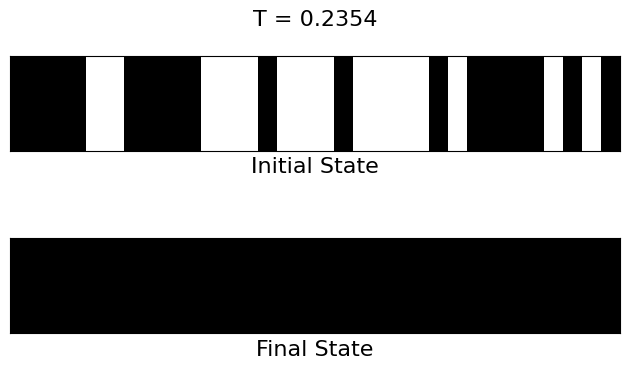

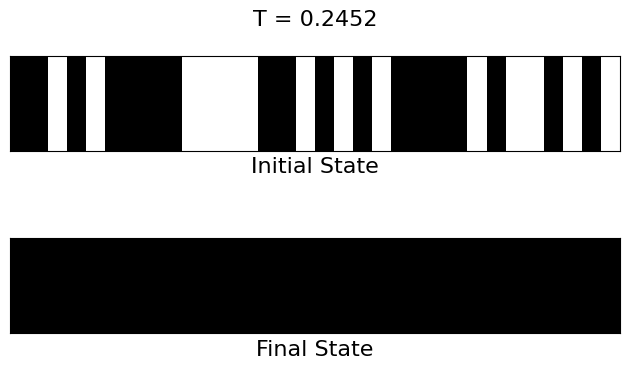

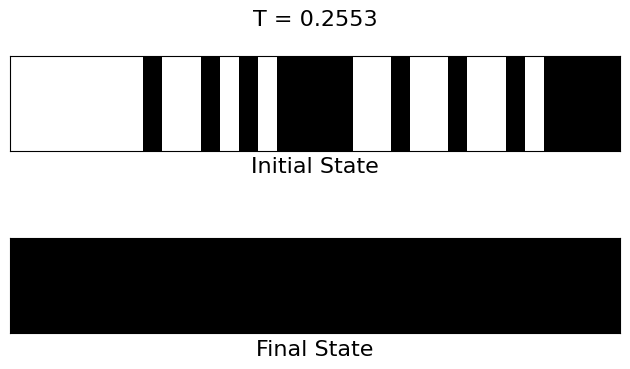

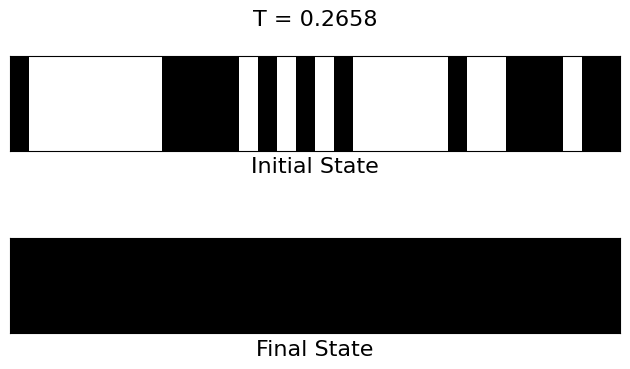

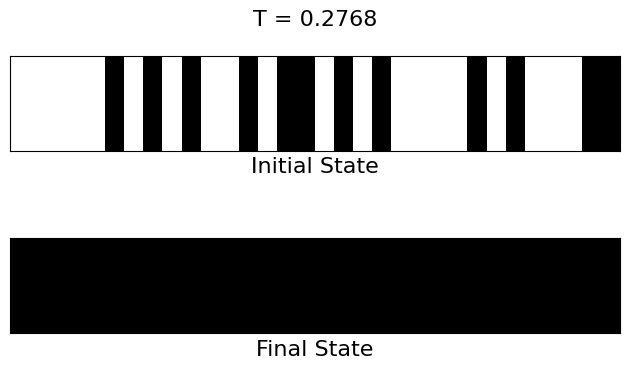

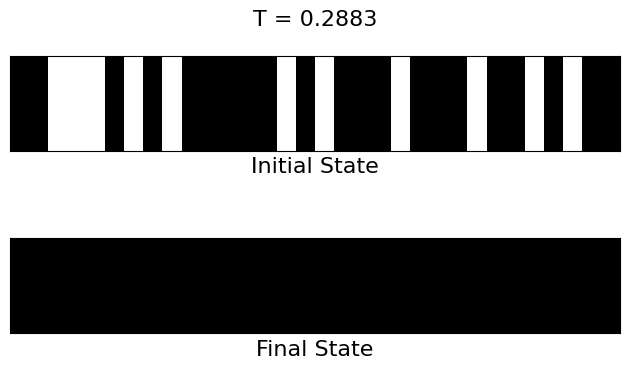

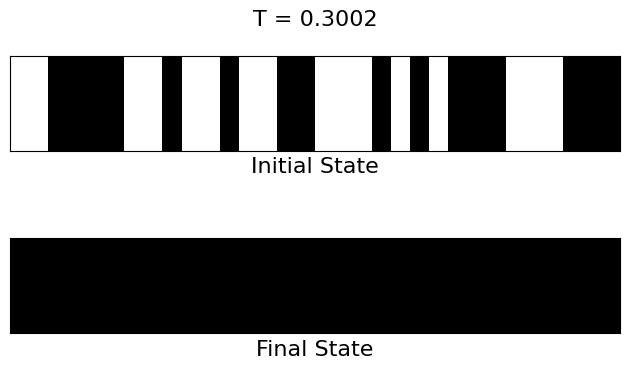

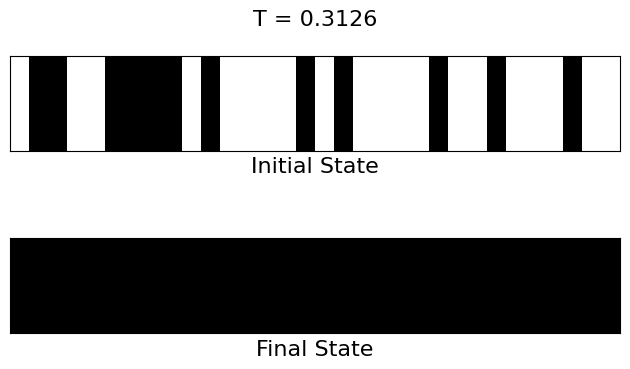

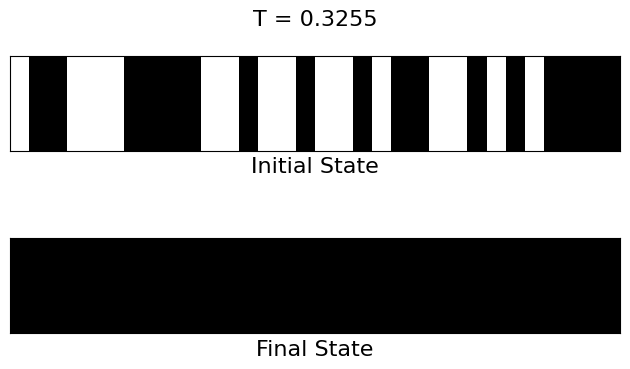

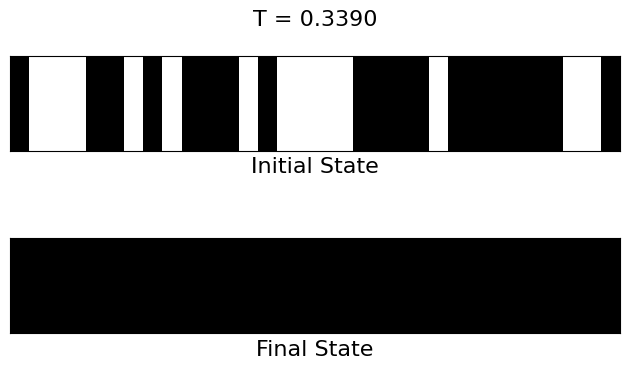

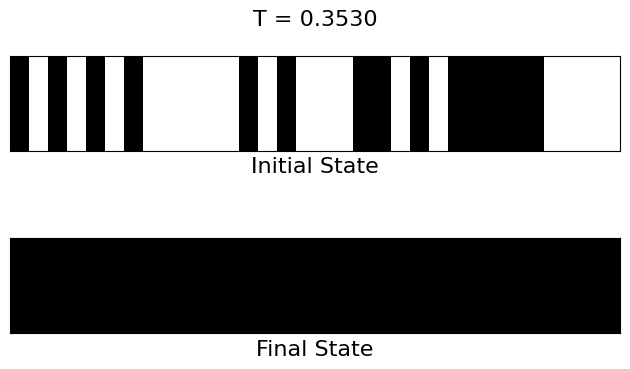

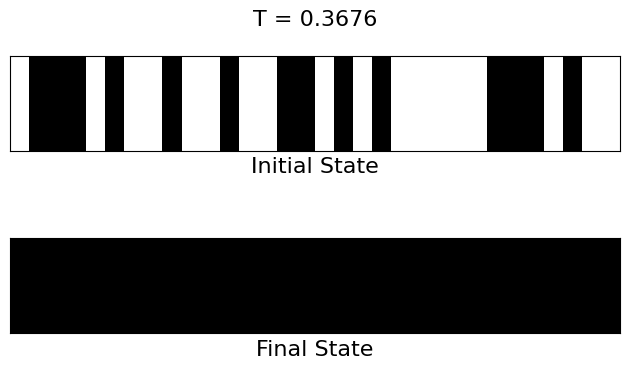

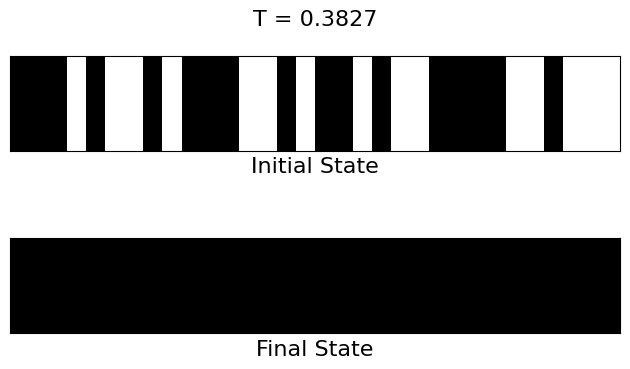

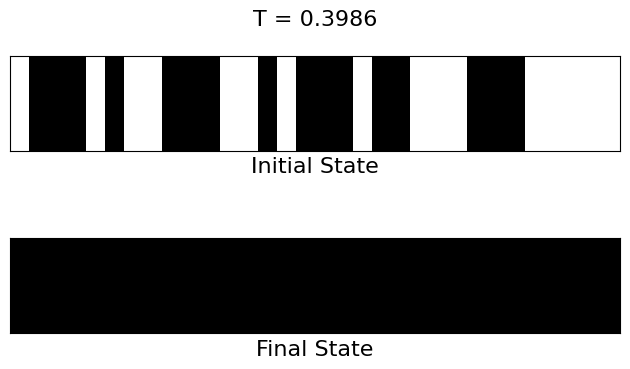

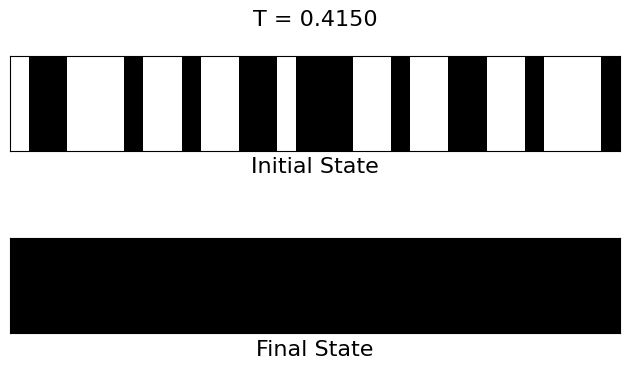

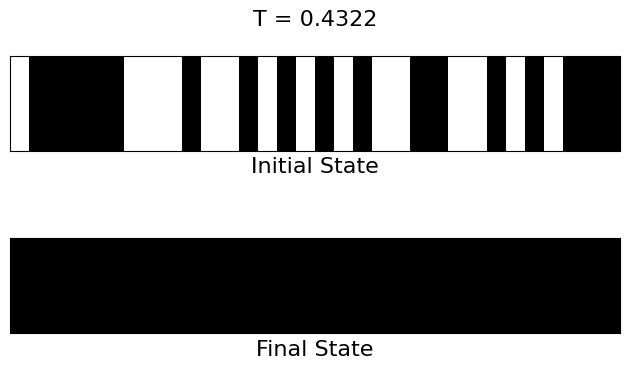

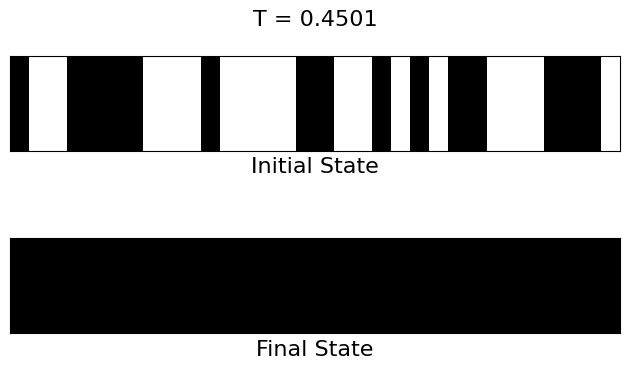

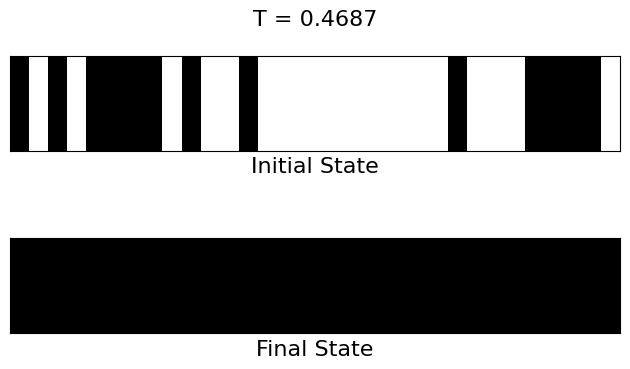

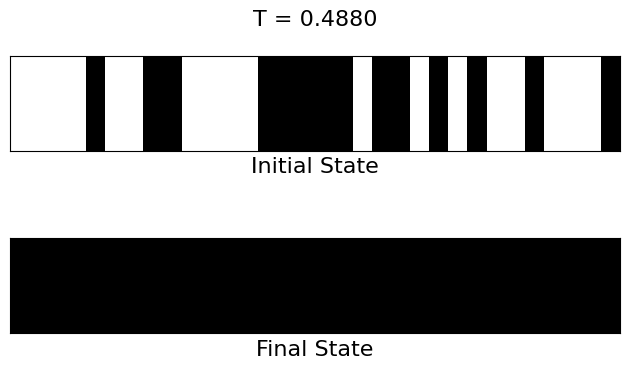

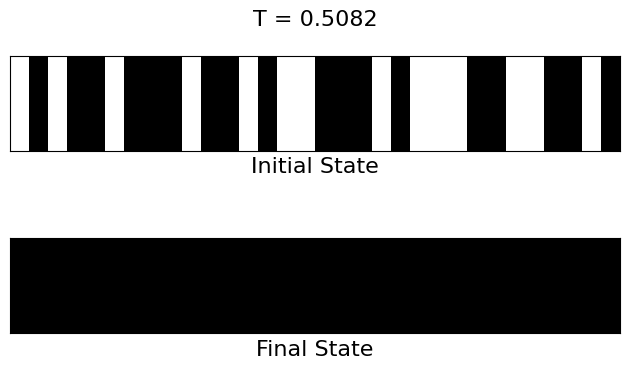

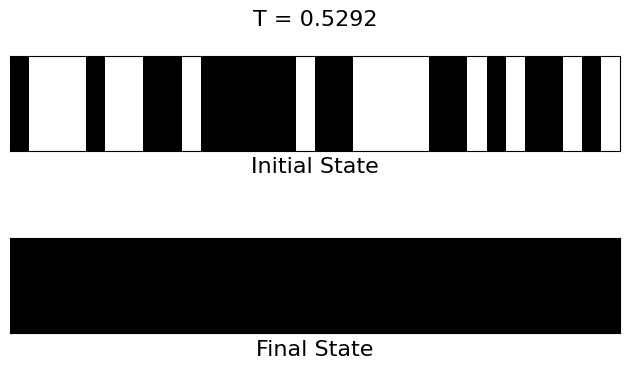

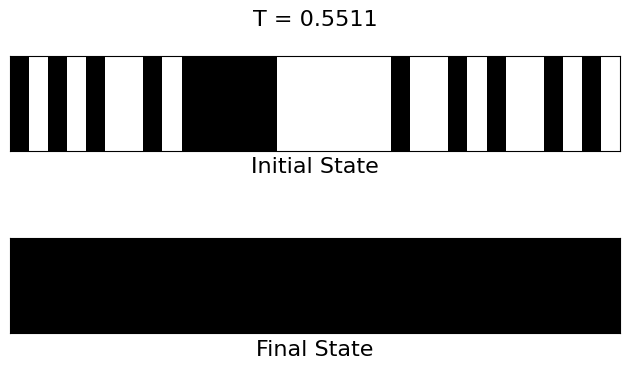

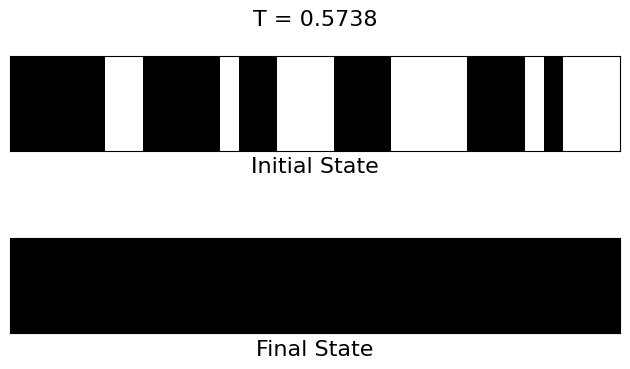

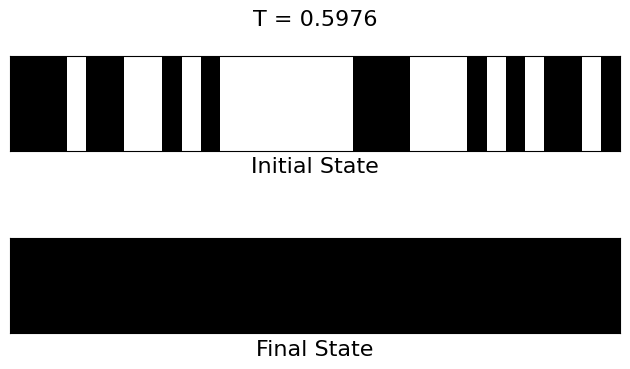

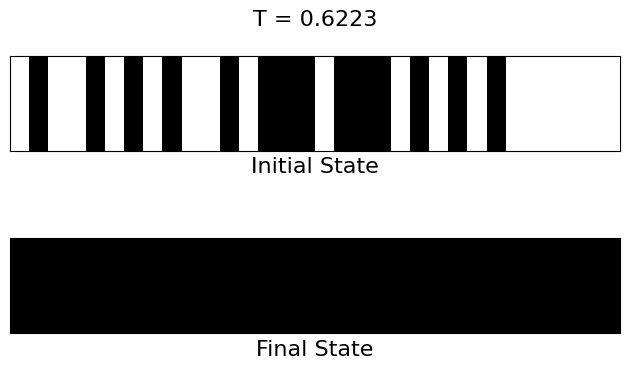

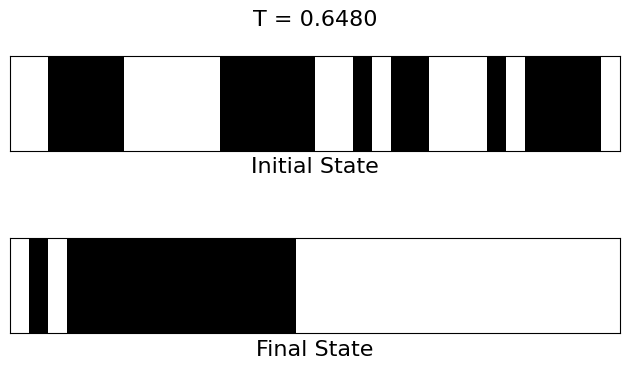

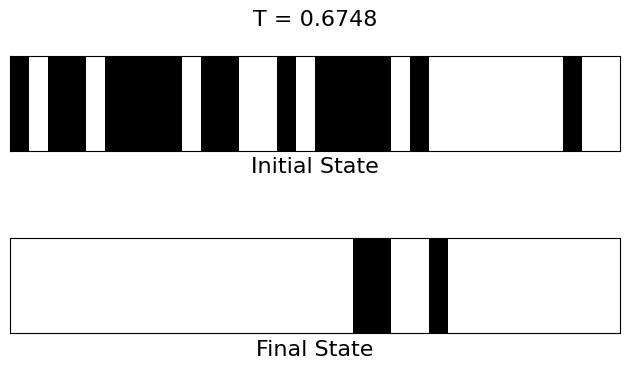

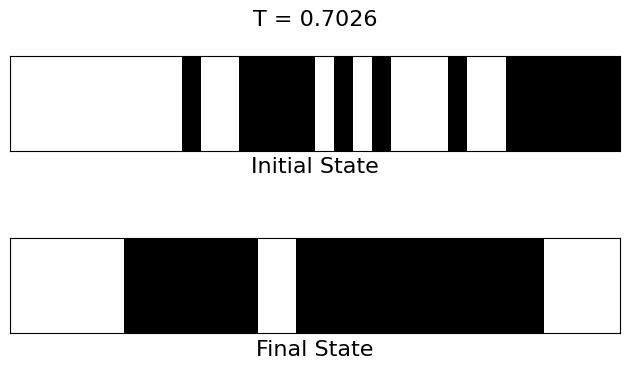

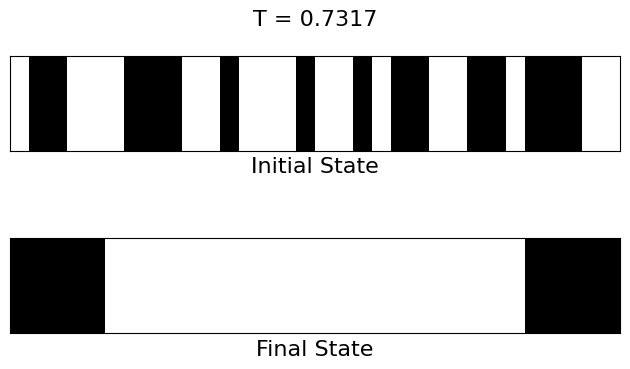

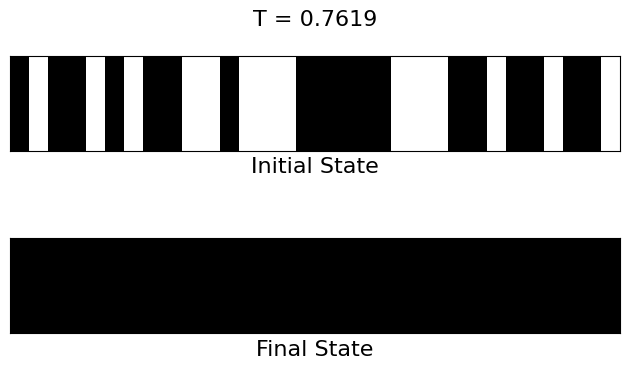

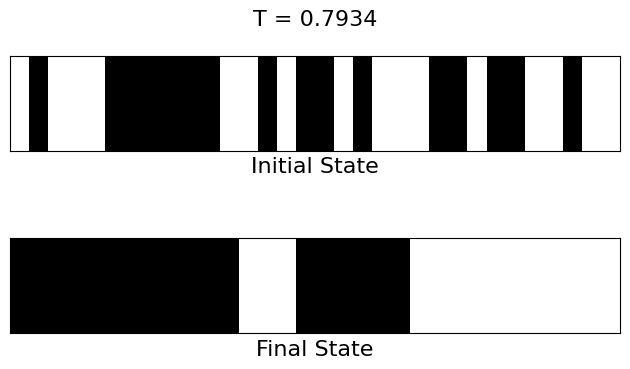

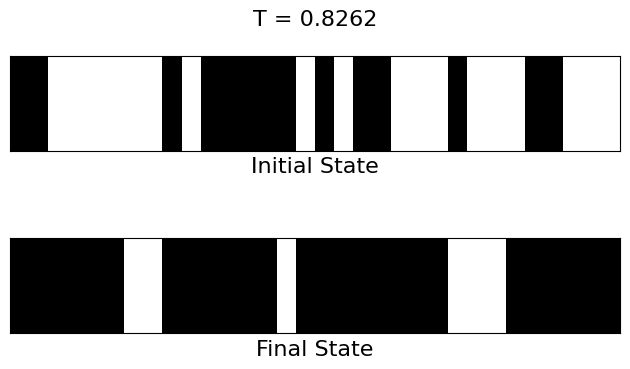

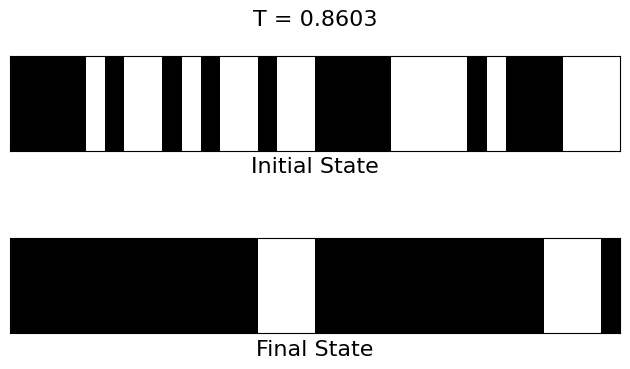

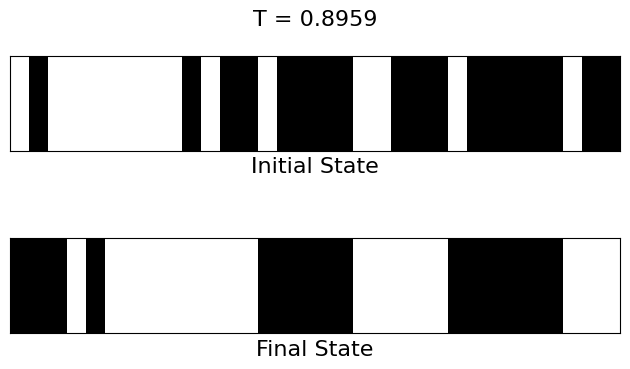

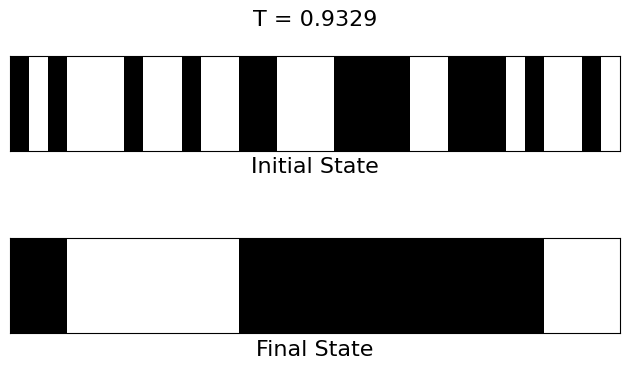

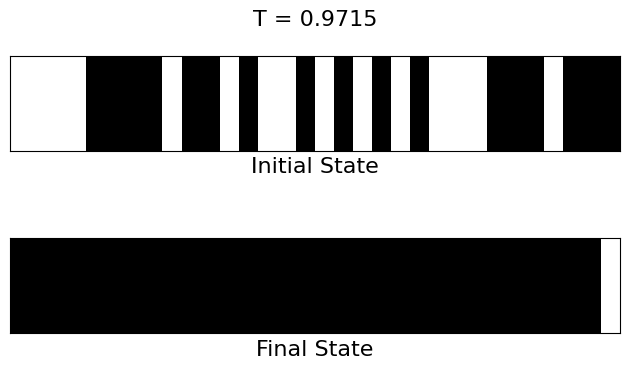

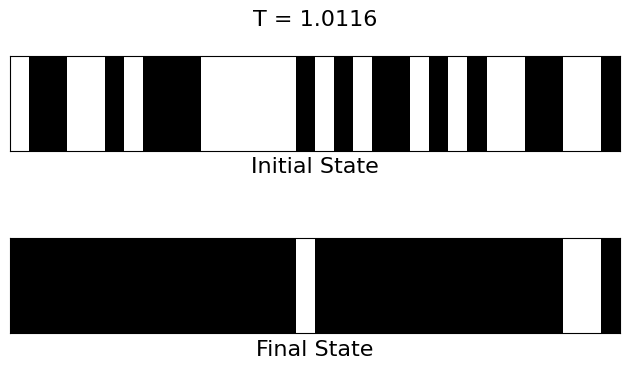

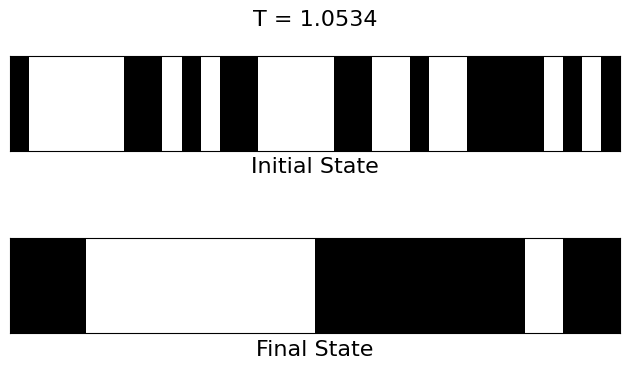

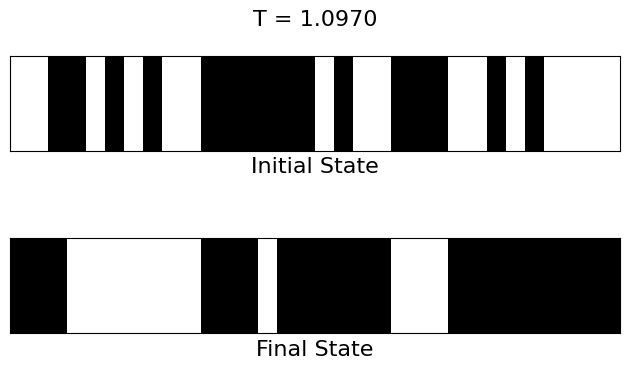

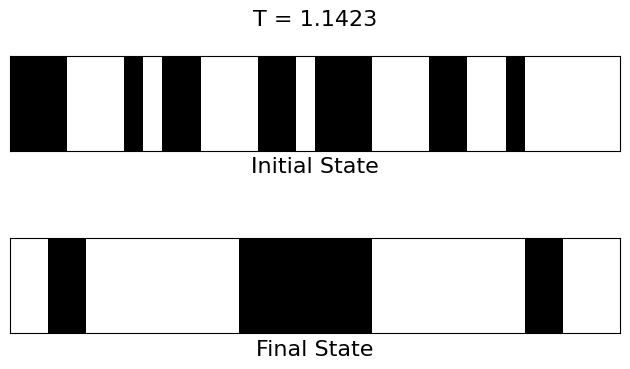

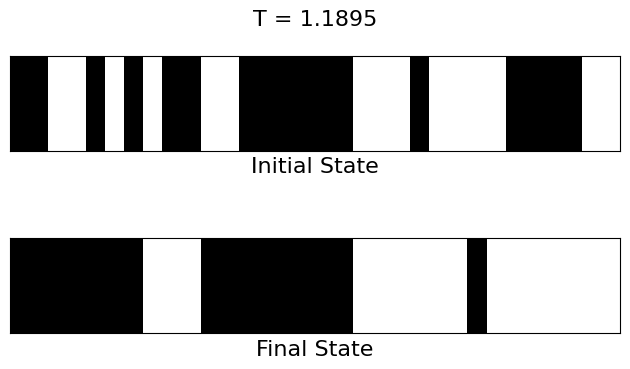

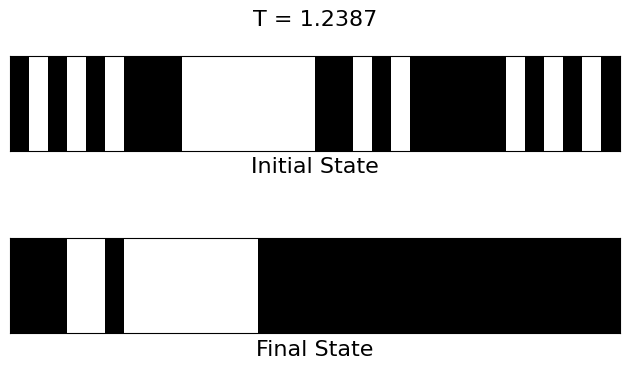

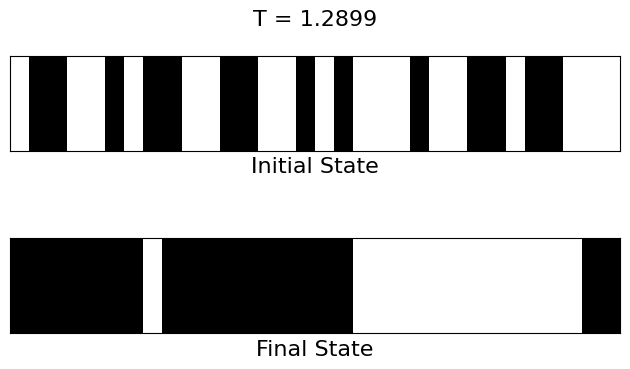

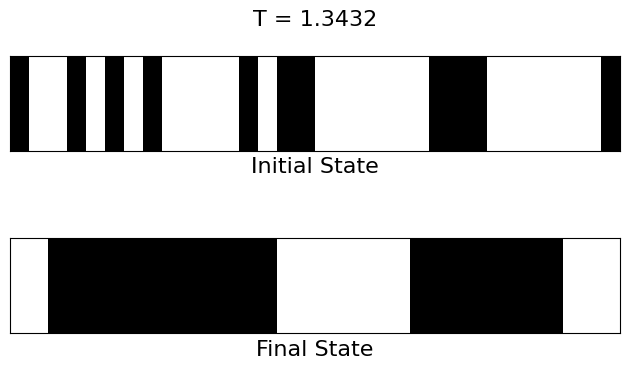

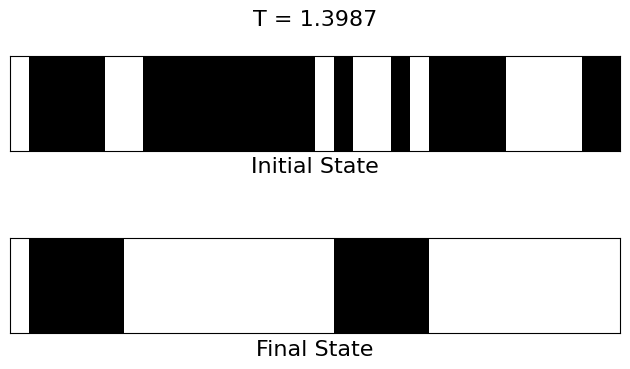

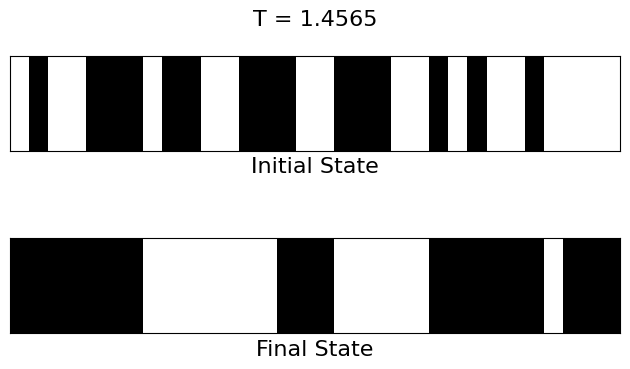

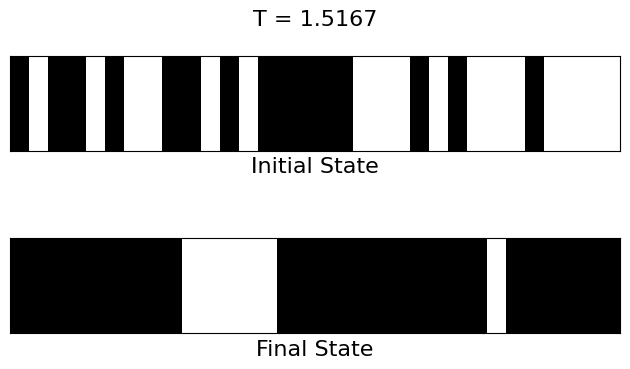

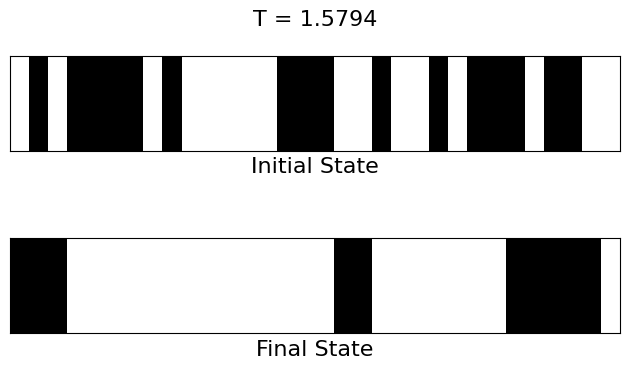

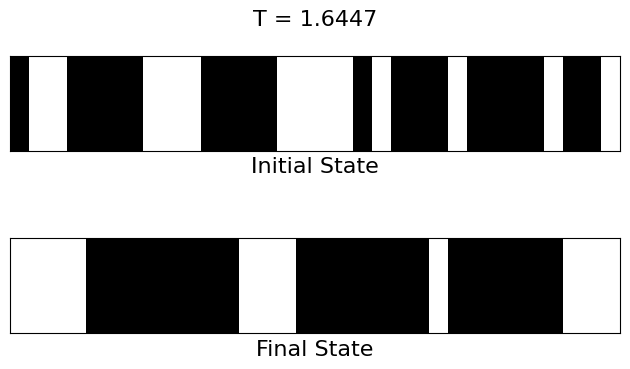

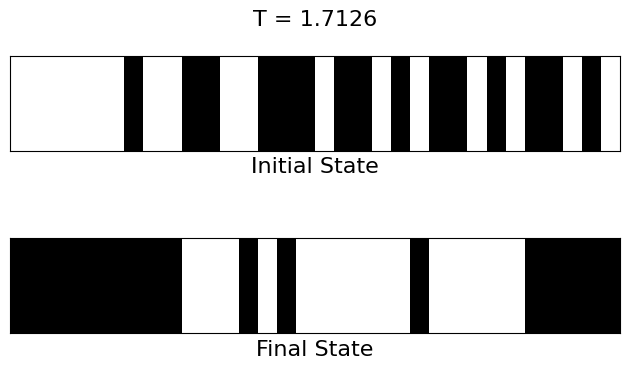

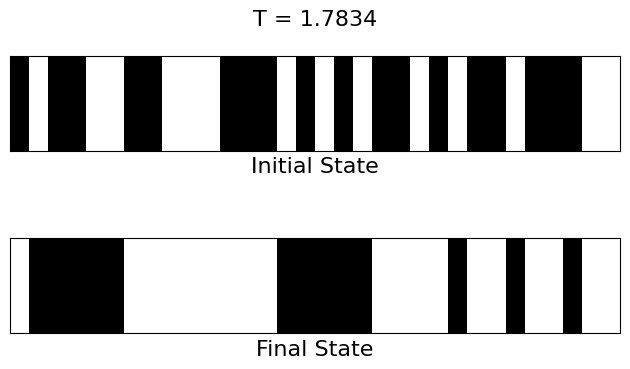

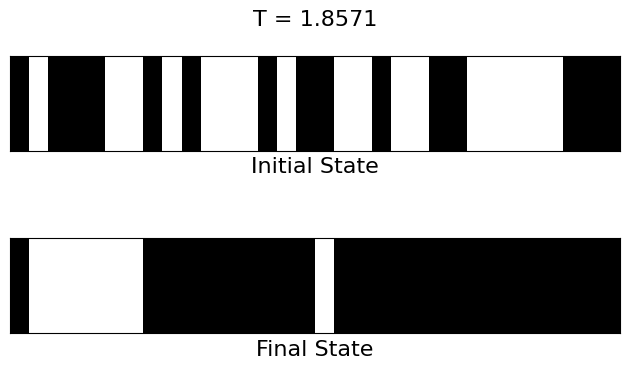

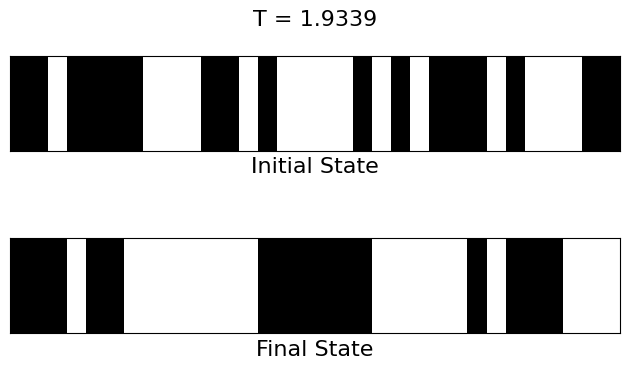

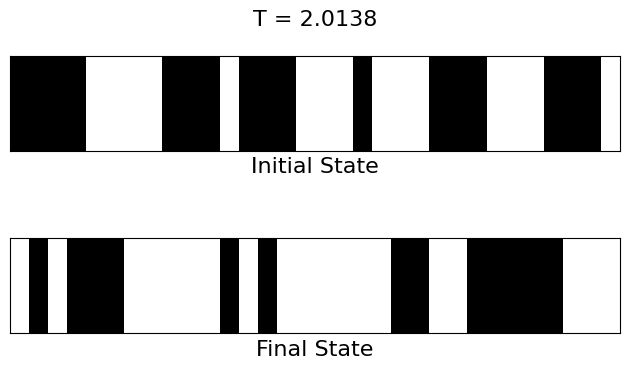

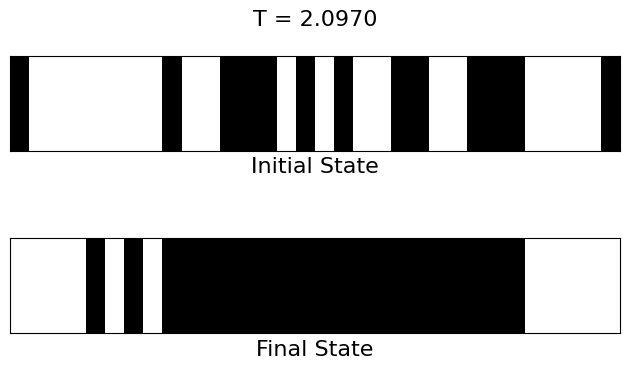

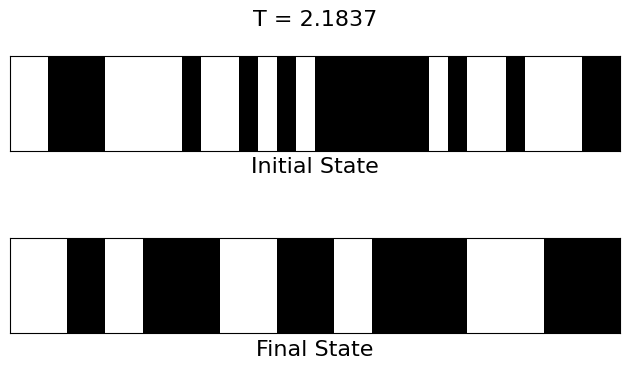

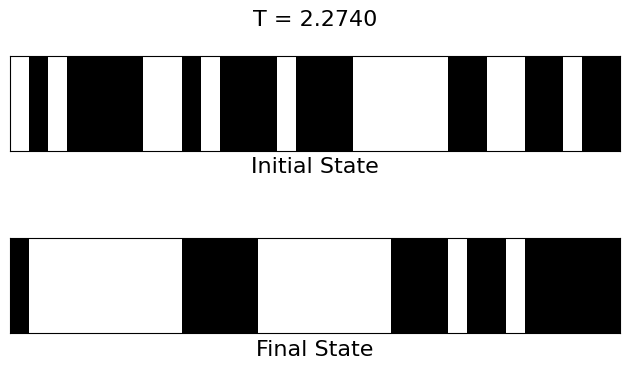

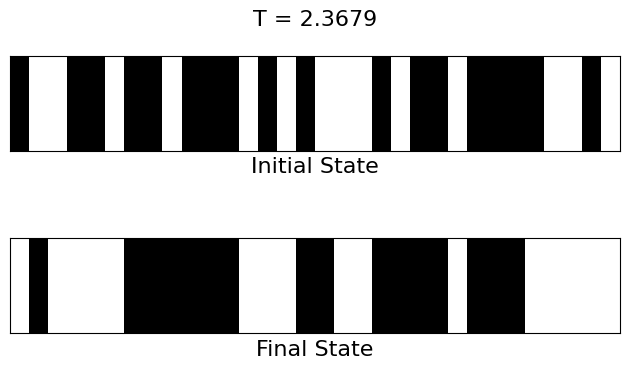

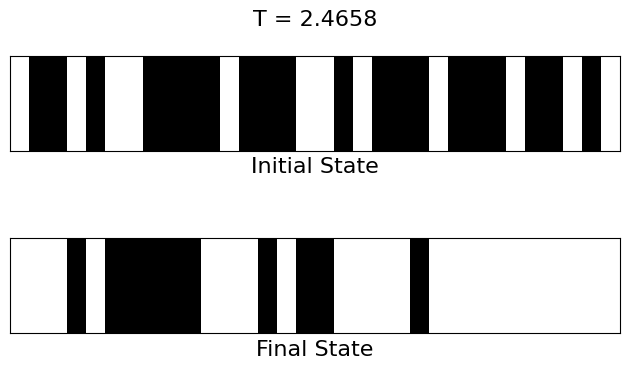

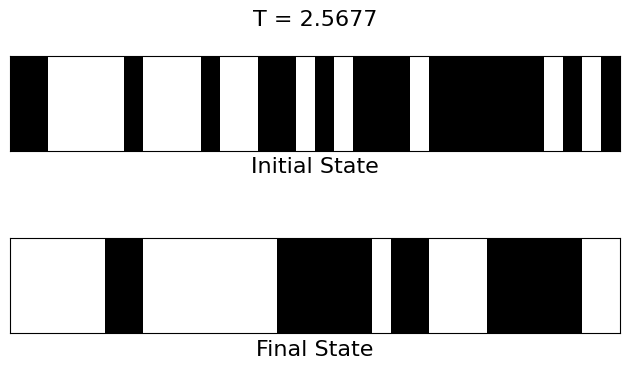

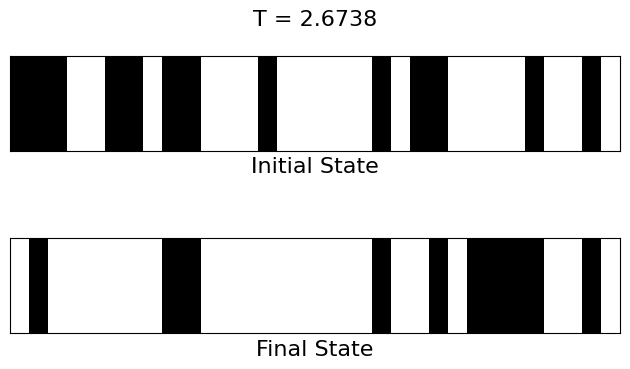

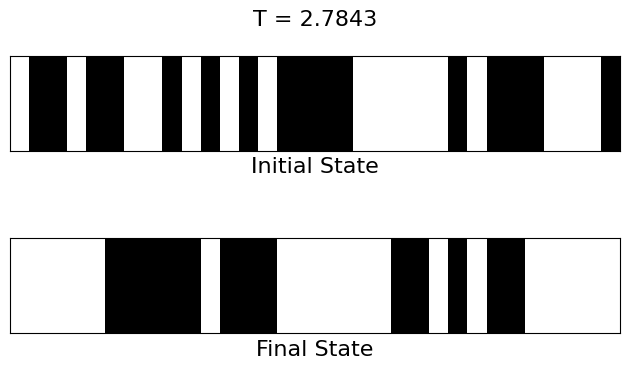

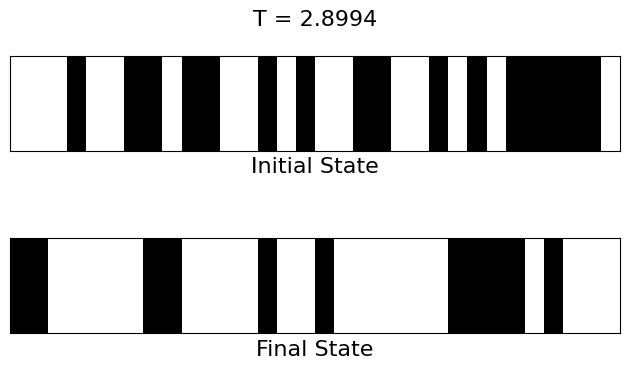

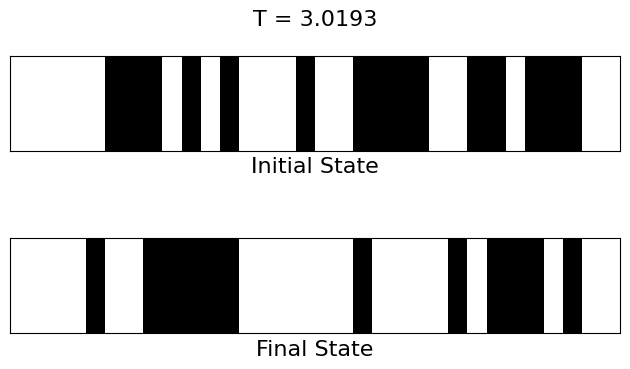

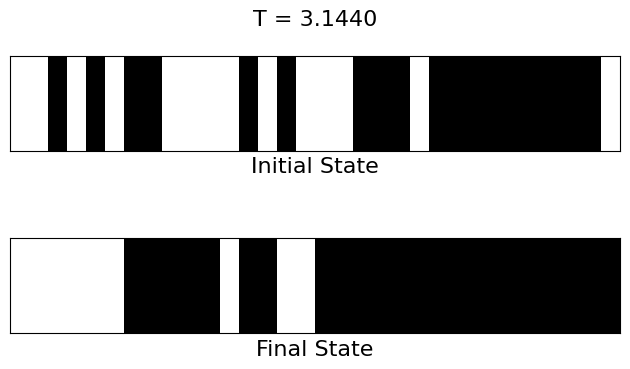

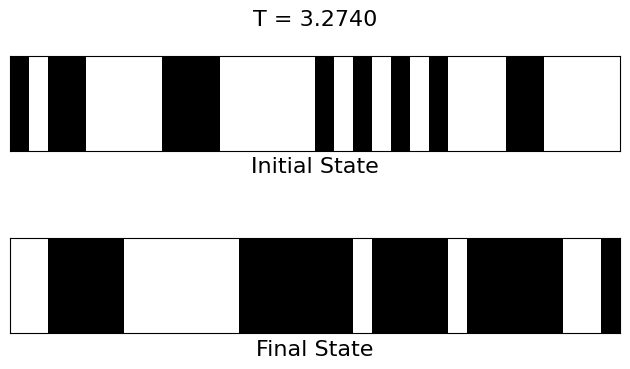

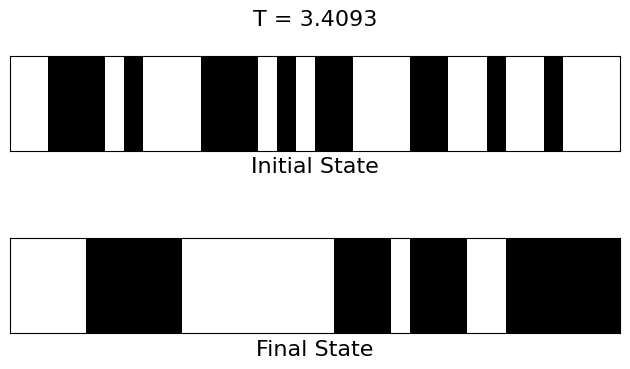

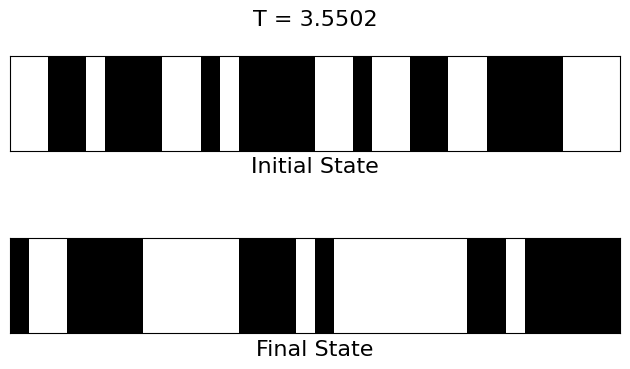

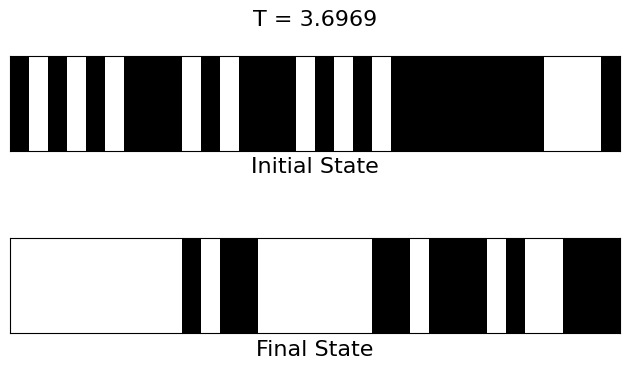

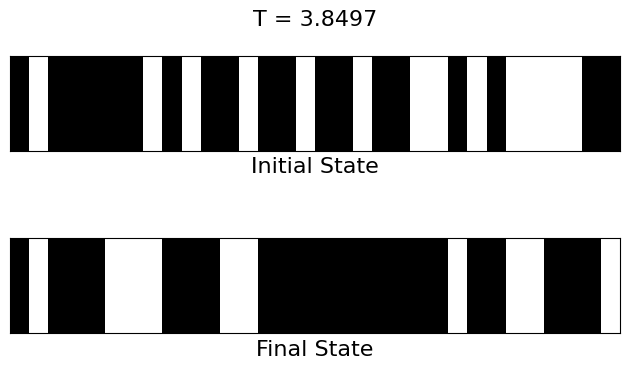

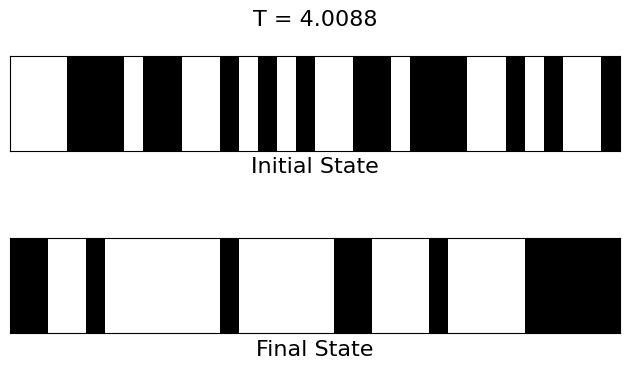

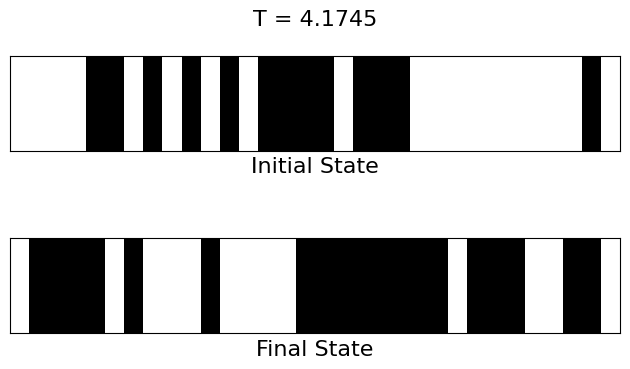

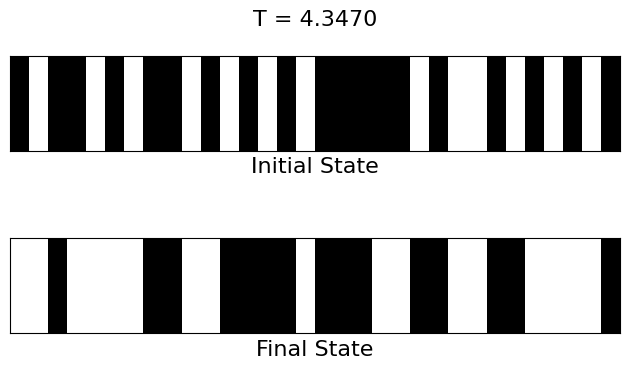

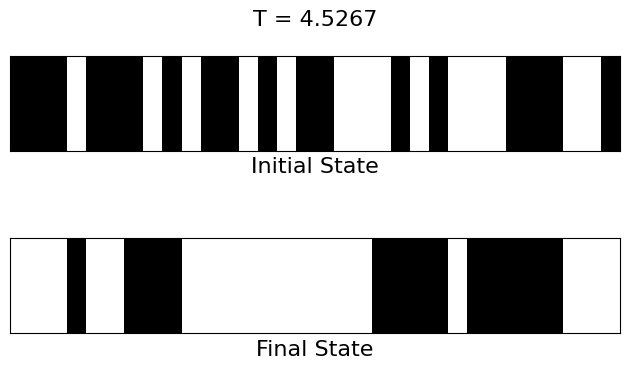

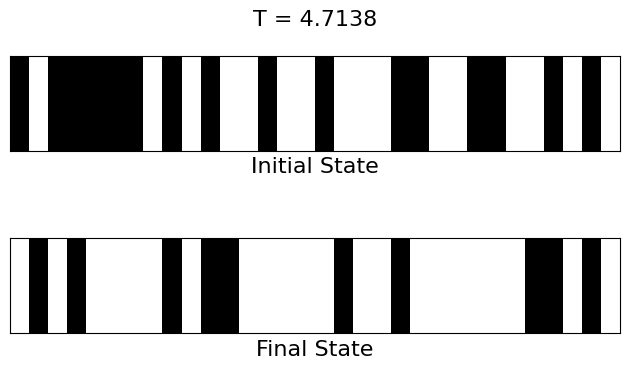

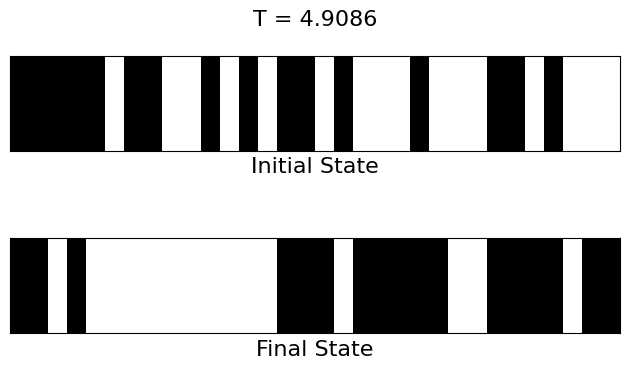

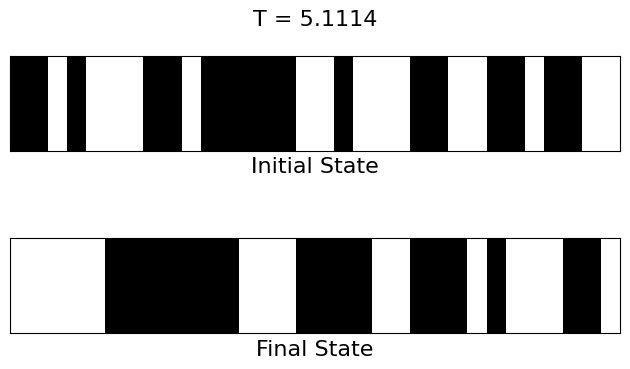

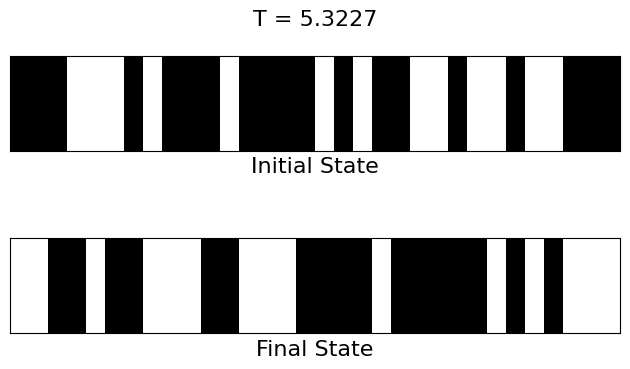

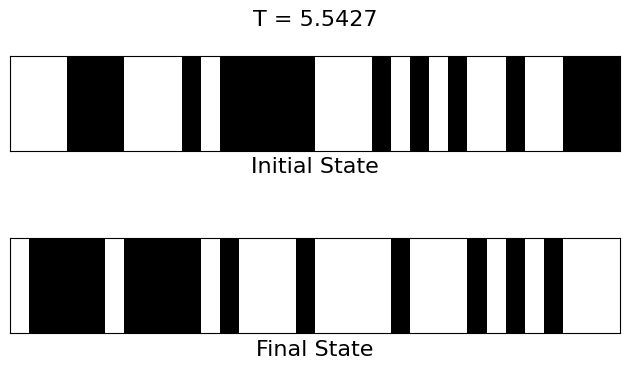

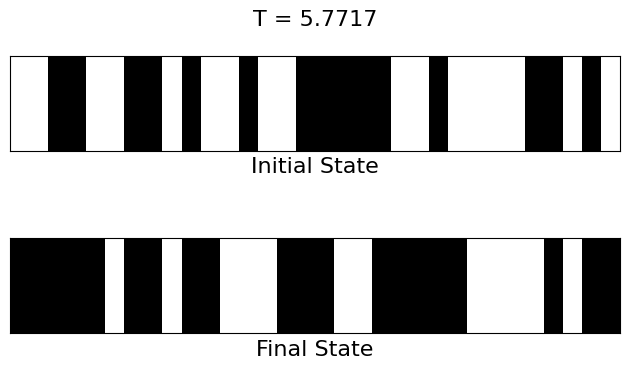

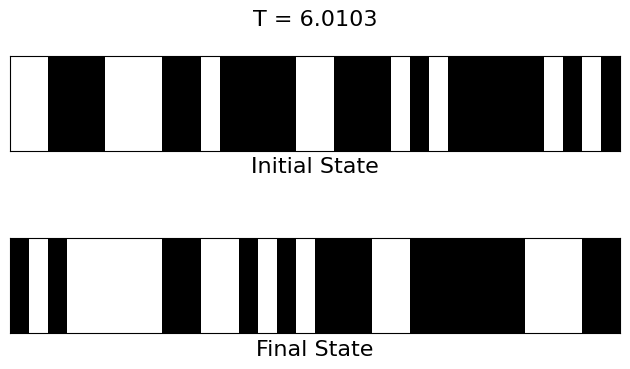

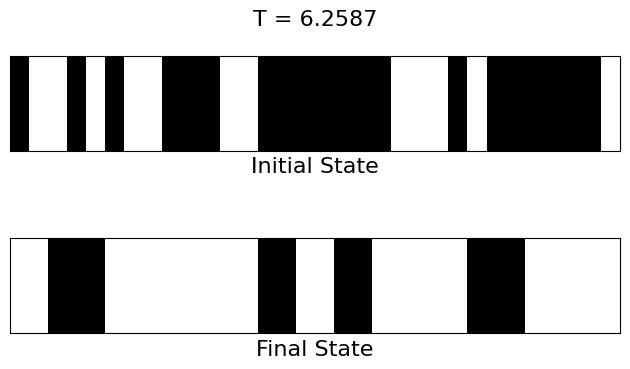

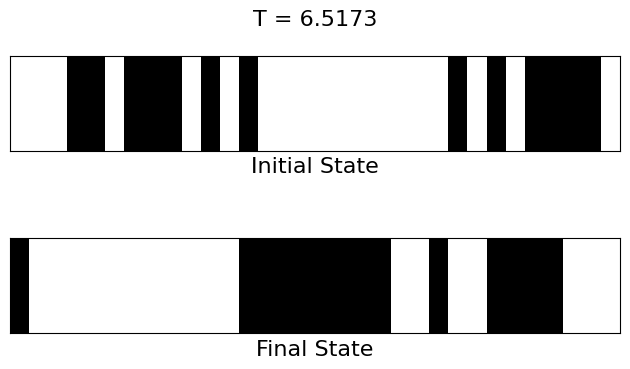

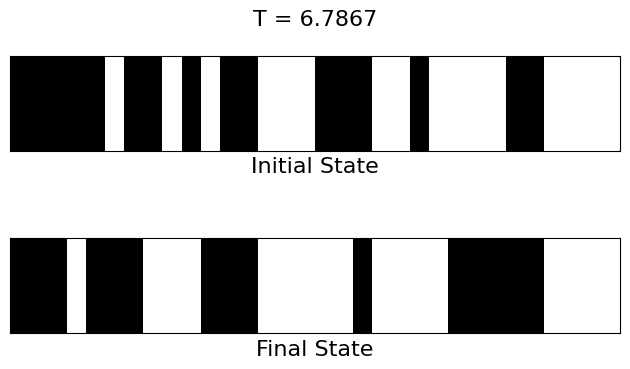

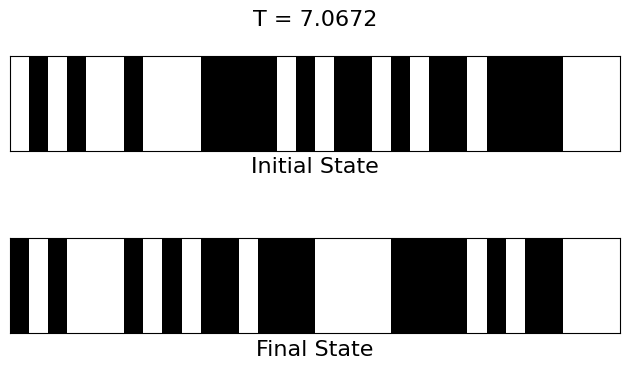

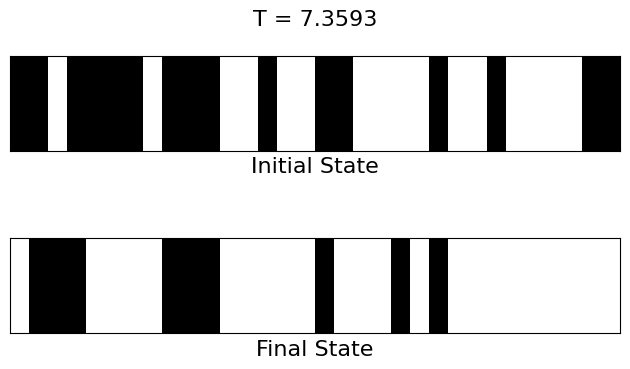

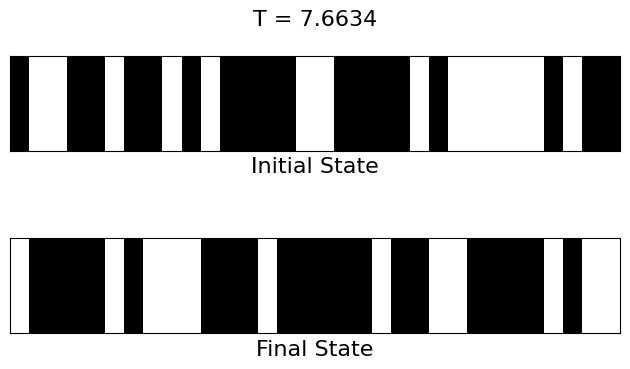

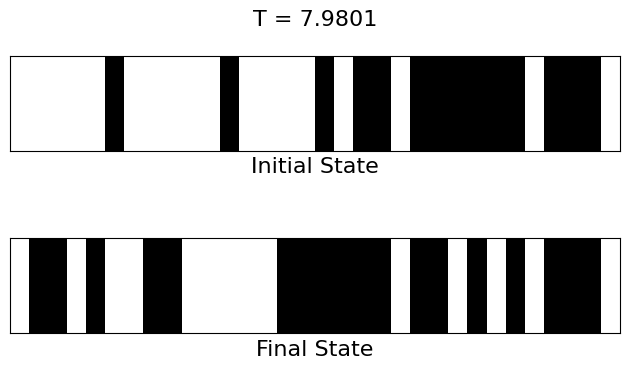

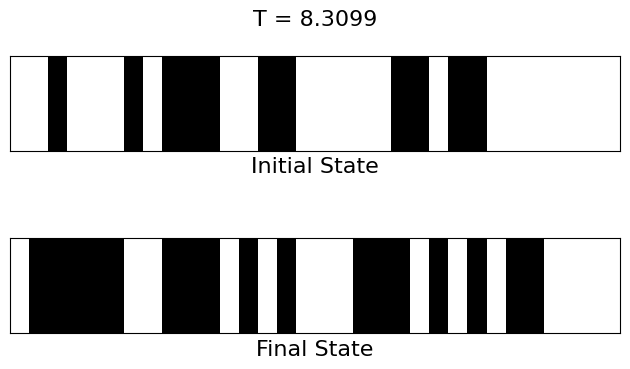

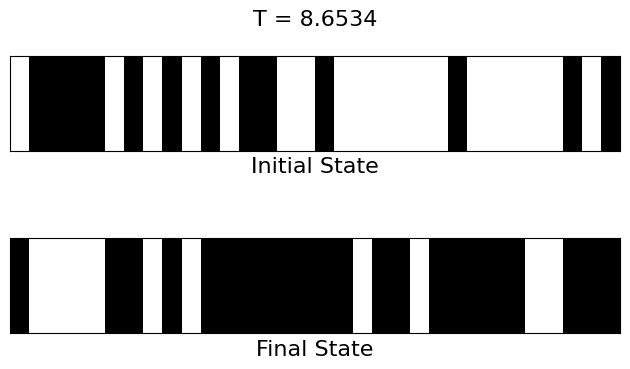

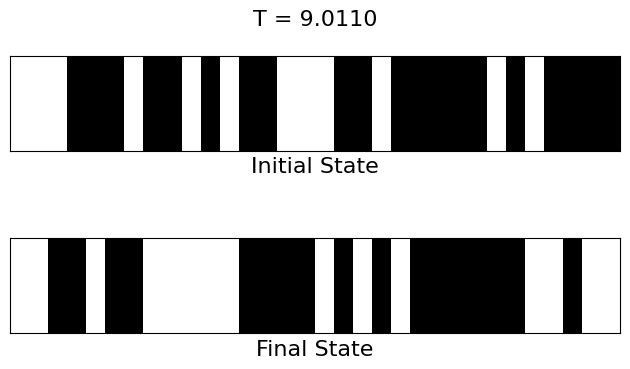

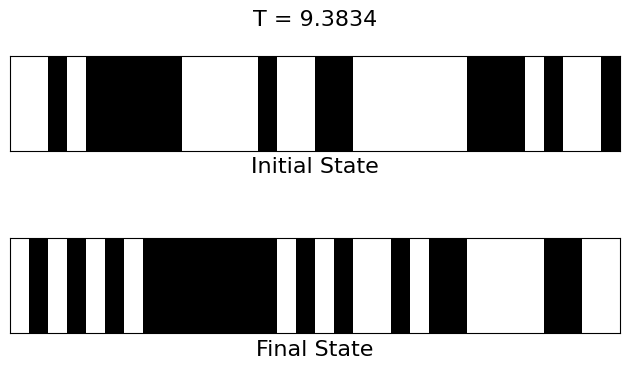

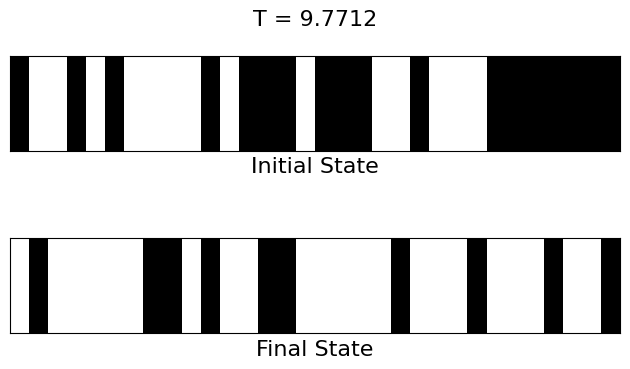

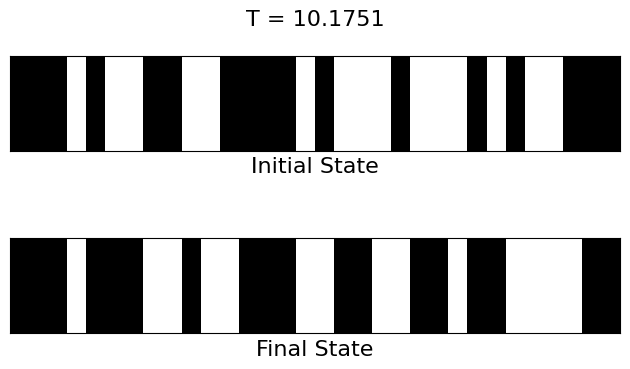

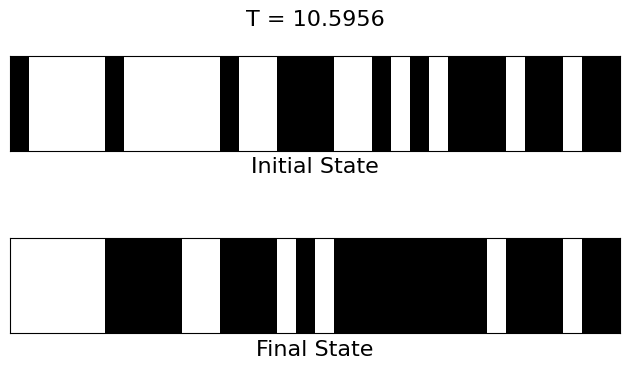

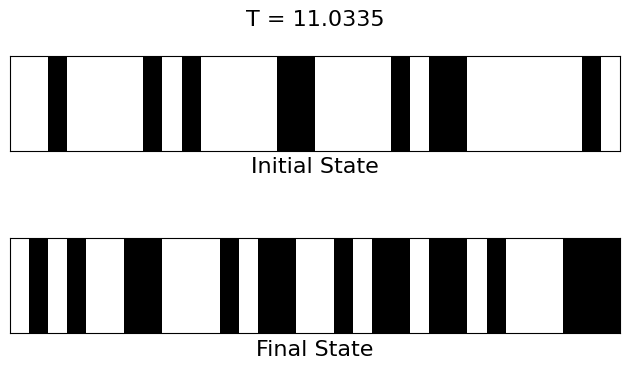

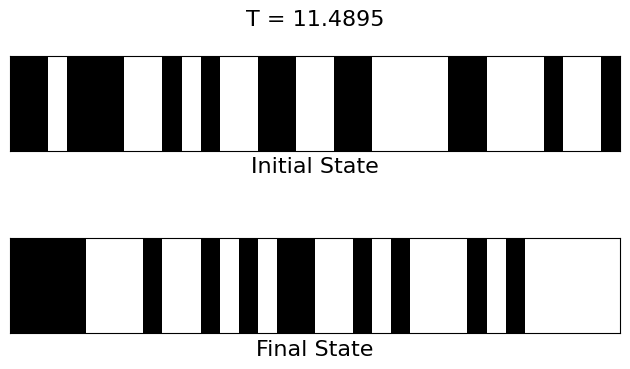

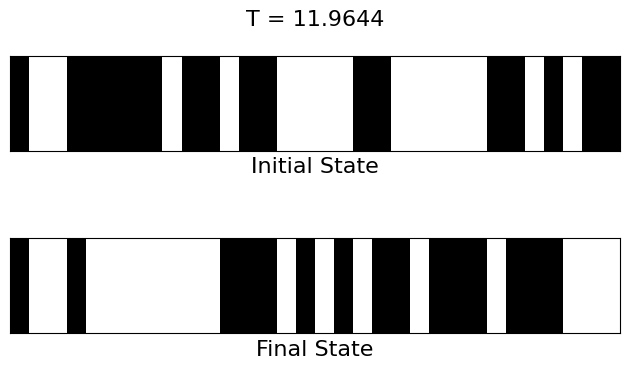

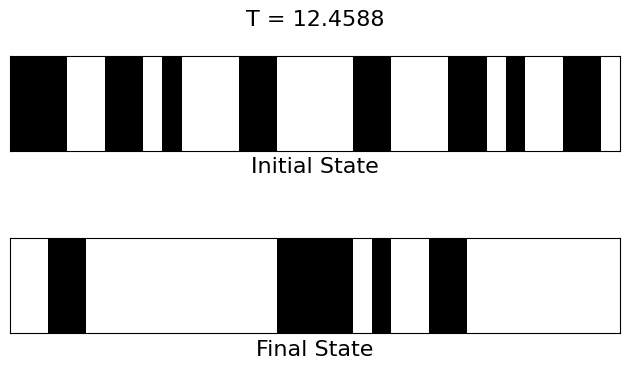

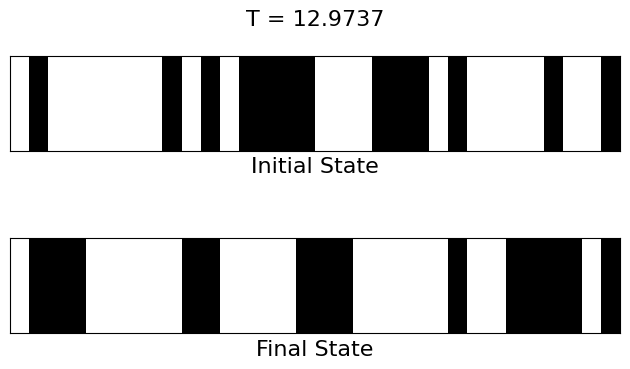

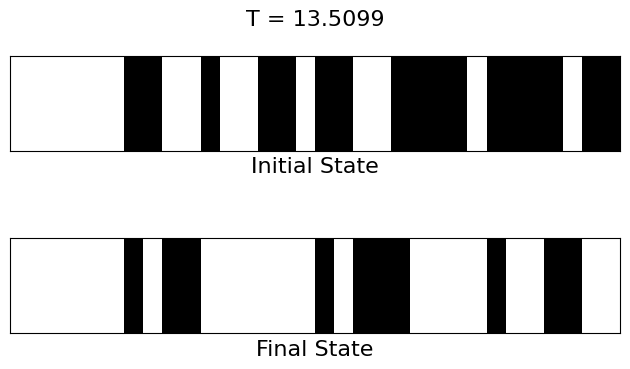

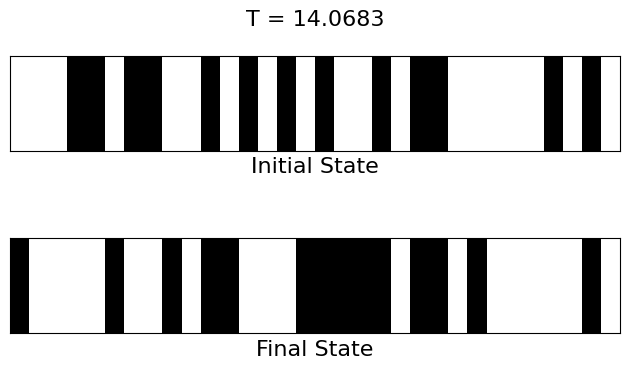

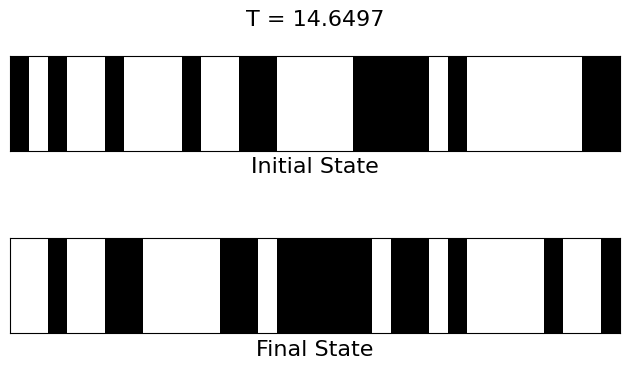

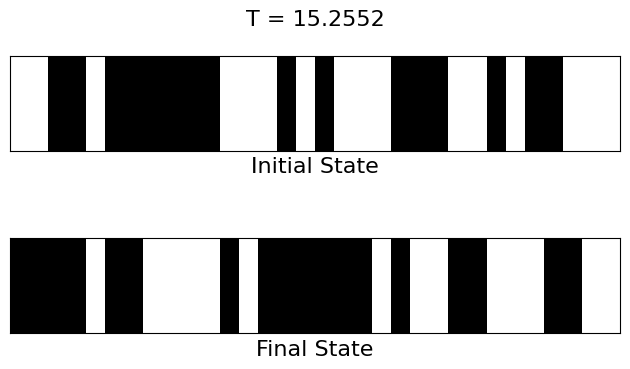

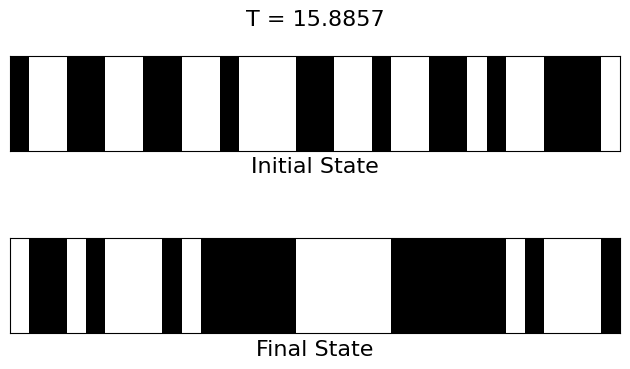

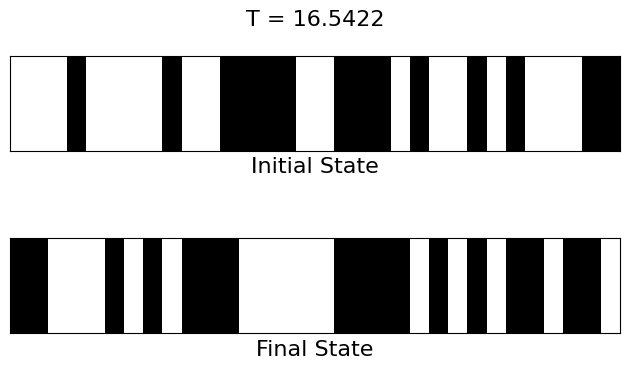

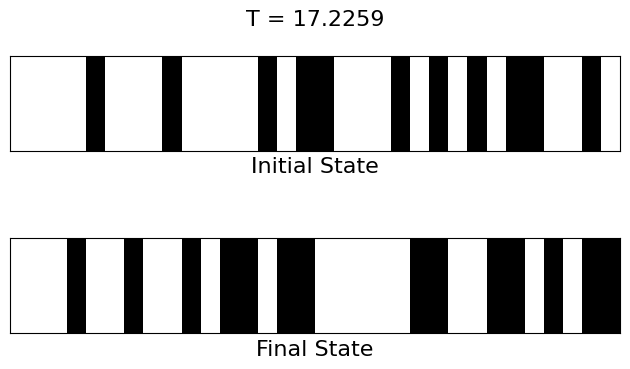

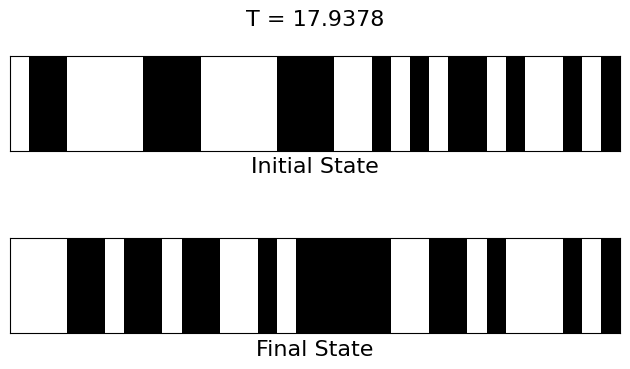

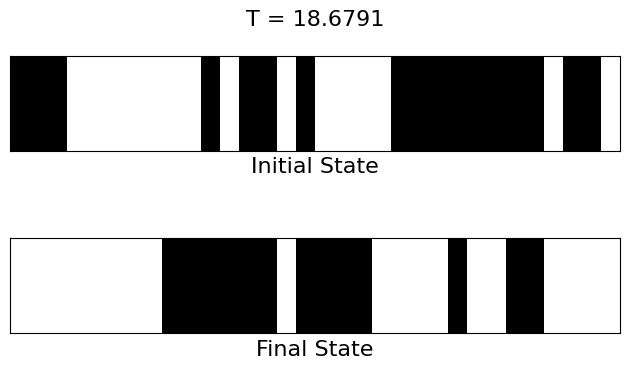

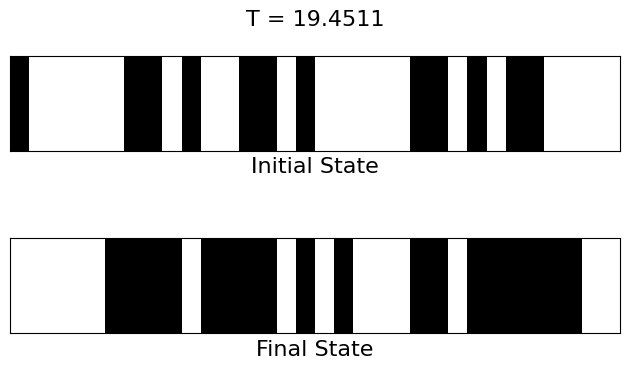

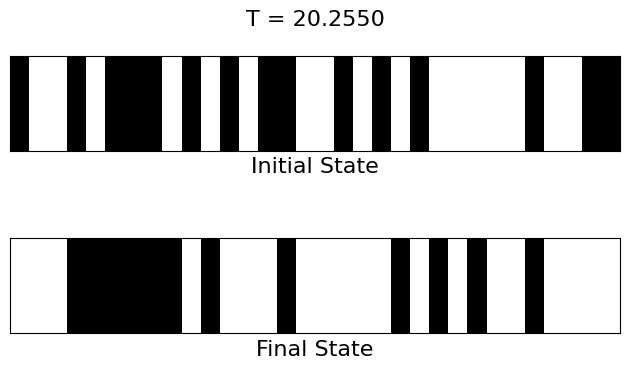

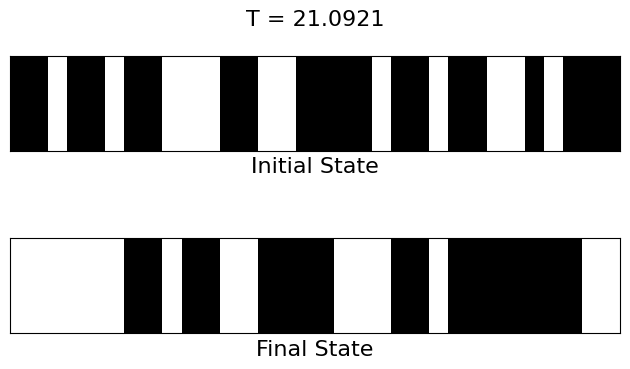

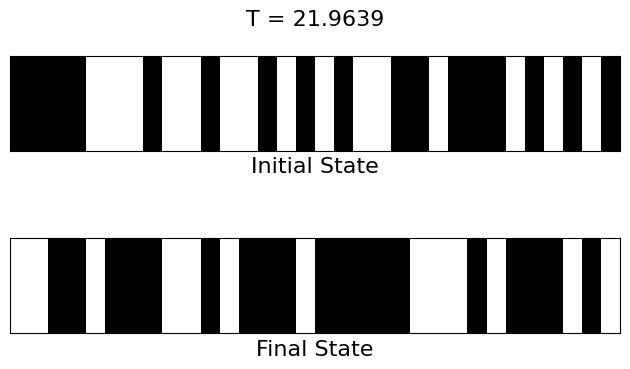

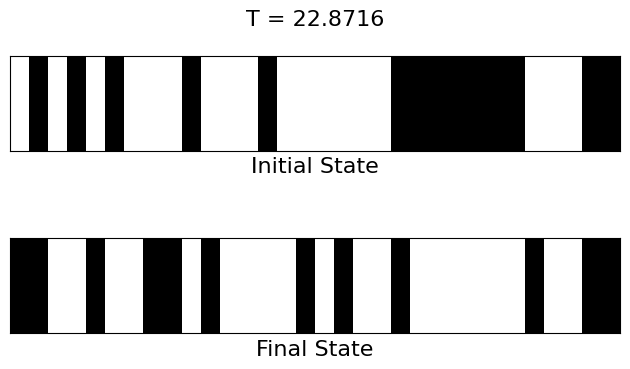

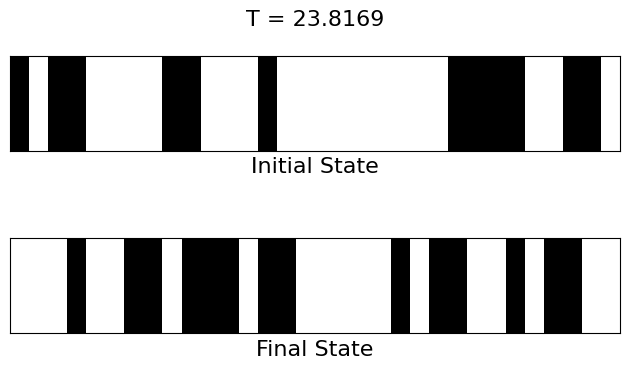

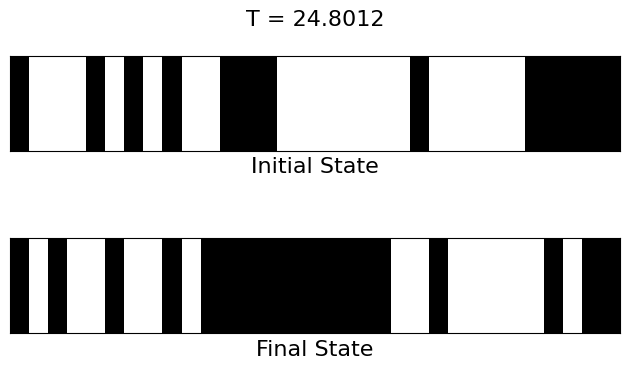

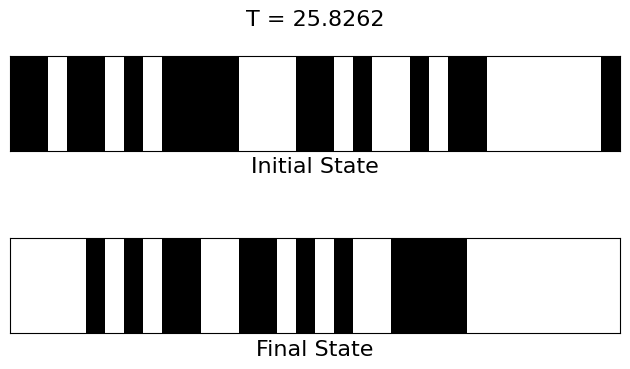

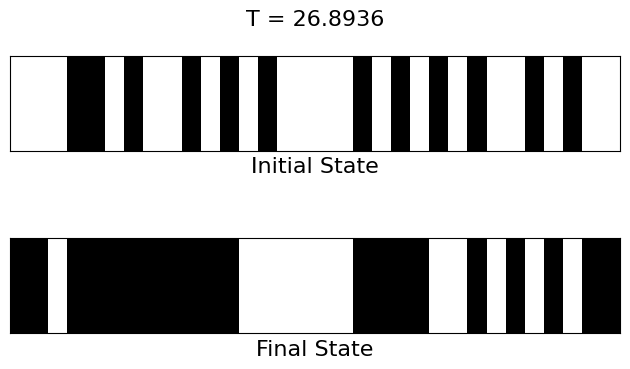

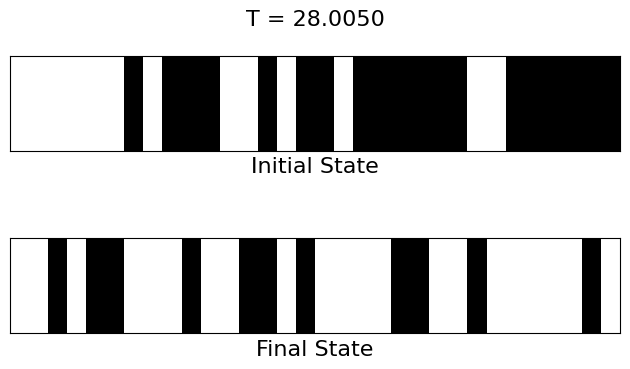

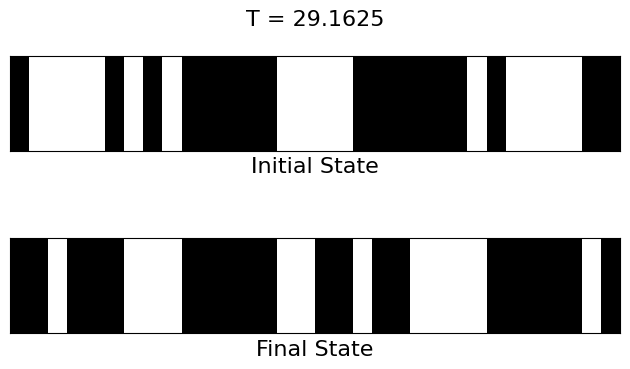

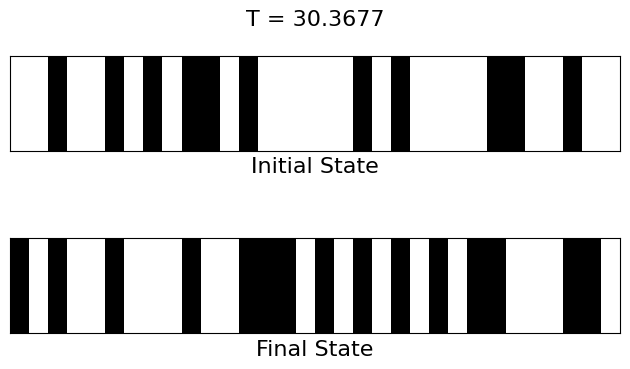

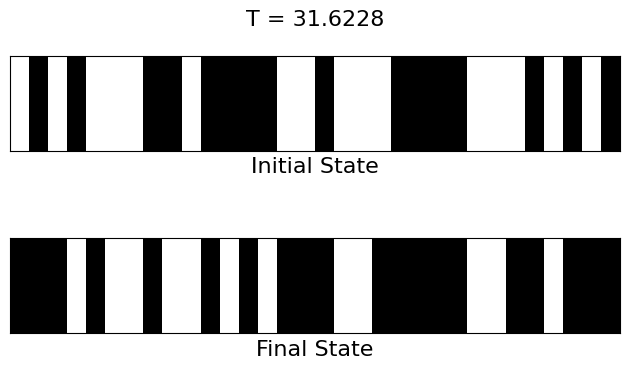

In [129]:
#Plot Spin Configurations

for i_T in range(Nt):
    f,ax = plt.subplots(2,1)
    ax[0].imshow(np.array([s_T[i_T][0] for i in range(5)]),cmap='gray')
    ax[0].set_xticks([]);
    ax[0].set_yticks([]);
    ax[0].xaxis.set_label_position('bottom')
    ax[0].set_xlabel('Initial State',fontsize=16)
    ax[1].imshow(np.array([s_T[i_T][1] for i in range(5)]),cmap='gray')
    ax[1].set_xticks([]);
    ax[1].set_yticks([]);   
    ax[1].xaxis.set_label_position('bottom')
    ax[1].set_xlabel('Final State',fontsize=16)
    f.suptitle(f'T = {Temps[i_T]:.4f}',y=.85,fontsize=16)
    plt.tight_layout()
    #plt.savefig(f'Figures/1D/1D-spinconfigplots/1Dconfig{i_T+1}.jpg')
    plt.show()